#Entregavel 2

In [ ]:
#Definindo semente

In [ ]:
#instalação das bibliotecas não nativas no Colab
!pip install boruta shap
!pip install xgboost
!pip install lightgbm
!pip install catboost
!pip install tabpfn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 724.4/724.4 kB 47.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.8/240.8 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 8.3 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [ ]:
def set_seed(seed=42):
    import random
    import numpy as np
    random.seed(seed)
    np.random.seed(seed)

    try:
        import torch
        torch.manual_seed(seed)
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    except ImportError:
        pass

    try:
        import tensorflow as tf
        tf.random.set_seed(seed)
    except ImportError:
        pass


In [ ]:
#manipulação de dados
import pandas as pd
import numpy as np

#deepcopy
from copy import deepcopy

#modelos que iremos aplicar nos dados
from xgboost import XGBClassifier

#obtenção do grid e randomized search
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_curve, auc

#visualização de dados
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

#seleção das variáveis
from boruta import BorutaPy

#importancia das variaveis
import shap

#definição de seed para reprodutibilidade
seed = 42

In [ ]:
# Instalando pacotes

In [ ]:
!pip install dfply
!pip install scikit-plot
!pip install graphviz
!pip install dtreeviz
!pip install imbalanced-learn
!pip install pycalib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 612.4/612.4 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.3/102.3 kB 7.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pycalib: filename=pycalib-0.1.0.dev6-py3-none-any.whl size=37283 sha256=dd81b7eb3a3f76f587600f491ea0f4154f6c1bdecdc280d05ef67c360fee3e03
  Stored in directory: /root/.cache/pip/wheels/db/bf/ea/6afc5c6734bb396fd469fd084fbc9c7bc8c34d70092d022389
Successfully built pycalib


In [ ]:
# Carregando pacotes

In [ ]:
import pandas as pd  # processamento de bancos de dados
import numpy as np  # processamento numérico
import matplotlib.pyplot as plt  # geração de gráficos
import seaborn as sns  # geração de gráficos alternativos

#manipulação de dados
import pandas as pd
import numpy as np

#deepcopy
from copy import deepcopy

#modelos que iremos aplicar nos dados
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from tabpfn import TabPFNClassifier

#obtenção do grid e randomized search
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, FixedThresholdClassifier
from sklearn.metrics import roc_curve, precision_recall_curve, auc, classification_report, confusion_matrix
from sklearn.calibration import calibration_curve

#visualização de dados
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

# Configuração de gráficos no notebook
%matplotlib inline
plt.rcParams["figure.figsize"] = [10, 5]
plt.style.use("fivethirtyeight")
%config InlineBackend.figure_format = 'retina'

# Configurações de fonte e matemática
from matplotlib import rc
rc('font', **{'family': 'sans-serif', 'sans-serif': ['DejaVu Sans'], 'size': 10})
rc('mathtext', **{'default': 'regular'})

#manipulação de dados
import pandas as pd
import numpy as np

#deepcopy
from copy import deepcopy

#modelos que iremos aplicar nos dados
from xgboost import XGBClassifier

#obtenção do grid e randomized search
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_curve, auc

#visualização de dados
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

#seleção das variáveis
from boruta import BorutaPy

#importancia das variaveis
import shap

# SCIKIT-LEARN

#bibliotecas do sklearn para preprocessamento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.metrics import (roc_curve, auc, confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score, roc_auc_score,
                             accuracy_score, brier_score_loss)
from sklearn.model_selection import (KFold, cross_val_score, train_test_split,
                                     GridSearchCV, RandomizedSearchCV)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.calibration import CalibratedClassifierCV
from sklearn.calibration import calibration_curve

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from catboost import CatBoostClassifier

from sklearn import preprocessing
from tabpfn import TabPFNClassifier

import shap

# Biblioteca dfply
from dfply import *

# Visualização de árvores de decisão
from dtreeviz.trees import *

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)

from collections import Counter

# Ignorar warnings
import warnings
warnings.filterwarnings("ignore")

# Definição de semente de aleatoriedade
np.random.seed(42)

#definição de seed para reprodutibilidade
seed = 42

#AP

In [ ]:
#mount google colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Import da base de treino e teste
df_train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/ML_2026/dados_treino_processados2_ap_2015_2024_aula.csv",
                        encoding='latin1', sep=",")
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/ML_2026/dados_teste_processados2_ap_2015_2024_aula.csv",
                        encoding='latin1', sep=",")

In [ ]:
#Separação das bases entre X_train, X_test, y_train, y_test
X_train=df_train.drop(columns = "cura")
y_train=df_train.cura
X_test=df_test.drop(columns = "cura")
y_test=df_test.cura

##• Proporção do desfecho (Obrigatório)

In [ ]:
#Visualização da proporção do desfecho na base de treino
y_train.value_counts(normalize=True)

,proportion
cura,
1,0.865482
0,0.134518


In [ ]:
#Visualização da proporção do desfecho na base de teste
y_test.value_counts(normalize=True)

,proportion
cura,
1,0.839437
0,0.160563


#3- Criação e Avaliação dos Modelos Iniciais

---



##Criação e Tuning dos Modelos

###Random Forest

In [ ]:
# Modelo e dicionário de busca
rf=RandomForestClassifier(random_state=seed)
rf_dict = {
    'n_estimators': np.arange(200, 501, 100),  # número de árvores, de 100 a 500
    'max_depth': np.arange(5, 15, 1),  # profundidade máxima da árvore, de 3 a 10
    'min_samples_split': np.arange(0.01, 0.06, 0.01),  # número mínimo de observaçoes ou proporcao para fazer a quebra
    'min_samples_leaf': [5,26,10],  # número mínimo de observaçoes em uma folha
    'max_features': [None, 'sqrt', 'log2']
}

# Criação do random search
rf_rs=RandomizedSearchCV(estimator=rf,
                         param_distributions=rf_dict,
                         scoring="roc_auc",
                         cv=5,
                         n_iter=20,
                         n_jobs=-1,
                         random_state=seed
                         )

# Fit do random search
rf_rs.fit(X_train, y_train)

# Print dos melhores hiperparâmetros
print("Hiperparametros do rf ", rf_rs.best_params_)

# Criação do modelo final
rf=rf_rs.best_estimator_


Hiperparametros do rf  {'n_estimators': np.int64(500), 'min_samples_split': np.float64(0.05), 'min_samples_leaf': 26, 'max_features': None, 'max_depth': np.int64(14)}


In [ ]:
# Generate predictions and probabilities
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# Métricas
auc_rf = roc_auc_score(y_test, y_prob_rf)

# Impressão
print(f'rf - ROC AUC: {auc_rf:.4f}')

rf - ROC AUC: 0.7360


In [ ]:
# Depois do Random Search
auc_rf_rs = roc_auc_score(y_test, y_prob_rf)
params_rf_rs = rf_rs.best_params_

In [ ]:
# Expandindo cada dicionário em colunas
df_rs = pd.DataFrame([params_rf_rs])
#df_hyperopt = pd.DataFrame([params_rf_hyperopt])
#df_optuna = pd.DataFrame([params_rf_optuna])

# Adicionando prefixo para identificar a origem
df_rs = df_rs.add_prefix("RS_")
#df_hyperopt = df_hyperopt.add_prefix("Hyperopt_")
#df_optuna = df_optuna.add_prefix("Optuna_")

# Concatenar em uma tabela única
df_params_rf_expanded = pd.concat([df_rs#, df_hyperopt, df_optuna
                                   ], axis=1)
df_params_rf_expanded.insert(0, 'Modelo', 'RandomForest')

# Mostrar tabela final
print("===== Tabela Hiperparâmetros Expandidos =====")
print(df_params_rf_expanded)

===== Tabela Hiperparâmetros Expandidos =====
         Modelo  RS_n_estimators  RS_min_samples_split  RS_min_samples_leaf  \
0  RandomForest              500                  0.05                   26   

  RS_max_features  RS_max_depth  
0            None            14  


In [ ]:
import pandas as pd

# Supondo que você já tenha:
# df_auc_rf =
#          Modelo  RandomSearch  Hyperopt   Optuna
# 0  RandomForest      0.687625  0.702539  0.69042

# Create df_auc_rf with available data
df_auc_rf = pd.DataFrame({
    'Modelo': ['RandomForest'],
    'RandomSearch': [auc_rf]
})

# 1️⃣ Encontrar a coluna com o maior valor (exceto a coluna 'Modelo')
best_method_rf = df_auc_rf.drop(columns='Modelo').idxmax(axis=1)[0]
best_auc = df_auc_rf.drop(columns='Modelo').max(axis=1)[0]
best_model = df_auc_rf['Modelo'][0]

print(f"✅ Modelo com maior AUC-ROC: {best_model} ({best_method_rf}) = {best_auc:.4f}")

✅ Modelo com maior AUC-ROC: RandomForest (RandomSearch) = 0.7360


In [ ]:
# ===============================
# Tabelas de hiperparâmetros expandidas
# Supondo que você tenha algo como df_params_expanded
# ===============================
# df_params_expanded =
#          Modelo  RS_n_estimators  RS_min_samples_split ... Optuna_max_features

# Determinar o melhor método
best_method_rf = df_auc_rf.drop(columns='Modelo').idxmax(axis=1)[0]
best_model_name = df_auc_rf['Modelo'][0]
print(f"✅ Melhor AUC-ROC detectada: {best_model_name} ({best_method_rf})")

# Mapear para os nomes de colunas no DataFrame de hiperparâmetros
method_prefix_map = {
    'RandomSearch': 'RS_',
    'Hyperopt': 'Hyperopt_',
    'Optuna': 'Optuna_'
}

prefix = method_prefix_map[best_method_rf]

# Extrair os hiperparâmetros correspondentes
best_params = {col.replace(prefix, ''): df_params_rf_expanded[col][0]
               for col in df_params_rf_expanded.columns if col.startswith(prefix)}

# Ajustar tipos de dados conforme necessário (int, float)
for key in ['n_estimators', 'max_depth', 'min_samples_leaf']:
    if key in best_params:
        best_params[key] = int(best_params[key])

# ===============================
# Treinar o modelo final com os melhores hiperparâmetros
# ===============================
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    **best_params,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# ===============================
# Predições e AUC
# ===============================
y_prob = rf.predict_proba(X_test)[:, 1]
from sklearn.metrics import roc_auc_score
auc_rf = roc_auc_score(y_test, y_prob)

print(f"✅ ROC AUC do melhor modelo ({best_method_rf}): {auc_rf:.4f}")

✅ Melhor AUC-ROC detectada: RandomForest (RandomSearch)
✅ ROC AUC do melhor modelo (RandomSearch): 0.7360


In [ ]:
# ===============================
# Mostrar os melhores hiperparâmetros do modelo selecionado
# ===============================
print(f"\n✅ Melhores hiperparâmetros do modelo {best_model_name} ({best_method_rf}):")

best_params_rf_completo = best_params

for param, value in best_params_rf_completo.items():
    print(f"{param}: {value}")


✅ Melhores hiperparâmetros do modelo RandomForest (RandomSearch):
n_estimators: 500
min_samples_split: 0.05
min_samples_leaf: 26
max_features: None
max_depth: 14


In [ ]:
# =========================
# SALVAR MODELO TREINADO
# =========================
import joblib  # para salvar o modelo
joblib.dump(rf, 'modelo_rf_ap_pre_selecao.pkl')

print("Modelo salvo com sucesso!")

Modelo salvo com sucesso!


###LGBM

In [ ]:
# Modelo e dicionário de busca
lgb=LGBMClassifier(random_state=seed)
lgb_dict = {
    'n_estimators': np.arange(200, 501, 100),  # número de árvores, de 1
    'max_depth': np.arange(5, 15, 1),  # profundidade máxima da árvore, de 3 a 10
    'min_data_in_leaf': [5,26,10],  # número mínimo de observaçoes em uma folha
    'learning_rate': np.logspace(-2, -0.7, 4),          # taxa de aprendizado, de 0.01 a 0.2 em escala logarítmica
    'subsample': np.linspace(0.6, 1.0, 3),              # proporção de amostras usadas por árvore
    'colsample_bytree': np.linspace(0.6, 1.0, 3),       # proporção de features usadas por árvore
    'reg_alpha': np.logspace(-3, 0, 4),                 # regularização L1, de 0.001 a 1
    'reg_lambda': np.linspace(1, 2, 3)                  # regularização L2
}

# Criação do random search
lgb_rs=RandomizedSearchCV(estimator=lgb,
                         param_distributions=lgb_dict,
                         scoring="roc_auc",
                         cv=5,
                         n_iter=20,
                         n_jobs=-1,
                         random_state=seed
                         )

# Fit do random search
lgb_rs.fit(X_train, y_train)

# Print dos melhores hiperparâmetros
print("Hiperparametros do lgb ", lgb_rs.best_params_)

# Criação do modelo final
lgb=lgb_rs.best_estimator_

[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Info] Number of positive: 682, number of negative: 106
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000536 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 123
[LightGBM] [Info] Number of data points in the train set: 788, number of used features: 56
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.865482 -> initscore=1.861591
[LightGBM] [Info] Start training from score 1.861591
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

#### Metricas threshold

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Probabilidades
y_prob_lgb = lgb.predict_proba(X_test)[:, 1]

# Aplica o threshold
threshold = 0.5
y_pred_lgb = (y_prob_lgb >= threshold).astype(int)

# Métricas
auc_lgb = roc_auc_score(y_test, y_prob_lgb)  # Continua usando probabilidade para o AUC

# Impressão
print(f'lgb - ROC AUC: {auc_lgb:.4f}')

[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
lgb - ROC AUC: 0.6880


In [ ]:
# Depois
auc_lgb_rs = roc_auc_score(y_test, y_prob_lgb)
params_lgb_rs = lgb_rs.best_params_

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score

# ===============================
# Mostrar os melhores hiperparâmetros do modelo selecionado
# ===============================

best_model_name = 'LightGBM'
best_method_lgb = "RandomSearch"

print(f"\n✅ Melhores hiperparâmetros do modelo {best_model_name} ({best_method_lgb}):")

best_params_lgb_completo = params_lgb_rs

for param, value in best_params_lgb_completo.items():
    print(f"{param}: {value}")


✅ Melhores hiperparâmetros do modelo LightGBM (RandomSearch):
subsample: 1.0
reg_lambda: 1.0
reg_alpha: 0.1
n_estimators: 200
min_data_in_leaf: 10
max_depth: 5
learning_rate: 0.02712272579332028
colsample_bytree: 1.0


In [ ]:
# =========================
# SALVAR MODELO TREINADO
# =========================
joblib.dump(lgb, 'modelo_lgb_ap_pre_selecao.pkl')

print("Modelo salvo com sucesso!")

Modelo salvo com sucesso!


###CatBoost

In [ ]:
# Modelo e dicionário de busca
cat = CatBoostClassifier(random_state=seed)
cat_dict = {
    'n_estimators': np.arange(200, 501, 100),  # número de árvores, de 100 a 500
    'max_depth': np.arange(3, 11, 1),  # profundidade máxima da árvore, de 3 a 10
    'min_data_in_leaf': [5,26,10],  # número mínimo de observaçoes em uma folha
    'subsample': np.linspace(0.6, 1.0, 3),              # proporção de amostras usadas por árvore
    'reg_lambda': np.linspace(1, 2, 3)                  # regularização L2

}

# Criação do random search
cat_rs=RandomizedSearchCV(estimator=cat,
                         param_distributions=cat_dict,
                         scoring="roc_auc",
                         cv=5,
                         n_iter=20,
                         n_jobs=-1,
                         random_state=seed
                         )

# Fit do random search
cat_rs.fit(X_train, y_train)

# Print dos melhores hiperparâmetros
print("Hiperparametros do cat ", cat_rs.best_params_)

# Criação do modelo final
cat=cat_rs.best_estimator_

0:	learn: 0.6697588	total: 47.5ms	remaining: 18.9s
1:	learn: 0.6504898	total: 48.5ms	remaining: 9.66s
2:	learn: 0.6307281	total: 49.3ms	remaining: 6.53s
3:	learn: 0.6138233	total: 50.1ms	remaining: 4.96s
4:	learn: 0.5983337	total: 50.8ms	remaining: 4.02s
5:	learn: 0.5811218	total: 51.6ms	remaining: 3.39s
6:	learn: 0.5679441	total: 52.4ms	remaining: 2.94s
7:	learn: 0.5559012	total: 53.1ms	remaining: 2.6s
8:	learn: 0.5413412	total: 53.9ms	remaining: 2.34s
9:	learn: 0.5303467	total: 54.6ms	remaining: 2.13s
10:	learn: 0.5199750	total: 55.4ms	remaining: 1.96s
11:	learn: 0.5087898	total: 56.2ms	remaining: 1.81s
12:	learn: 0.4998442	total: 56.9ms	remaining: 1.69s
13:	learn: 0.4900014	total: 57.7ms	remaining: 1.59s
14:	learn: 0.4815787	total: 58.5ms	remaining: 1.5s
15:	learn: 0.4744892	total: 59.2ms	remaining: 1.42s
16:	learn: 0.4666714	total: 60ms	remaining: 1.35s
17:	learn: 0.4591587	total: 60.8ms	remaining: 1.29s
18:	learn: 0.4533265	total: 61.5ms	remaining: 1.23s
19:	learn: 0.4480962	total

#### Metricas threshold

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Probabilidades
y_prob_cat = cat.predict_proba(X_test)[:, 1]

# Aplica o threshold
threshold = 0.5
y_pred_cat = (y_prob_cat >= threshold).astype(int)

# Métricas
auc_cat = roc_auc_score(y_test, y_prob_cat)  # Continua usando probabilidade para o AUC

# Impressão
print(f'cat - ROC AUC: {auc_cat:.4f}')


cat - ROC AUC: 0.7022


In [ ]:
# Depois
auc_cat_rs = roc_auc_score(y_test, y_prob_cat)
params_cat_rs = cat_rs.best_params_

In [ ]:
best_model_name = 'CatBoost'
best_method_cat = "RandomSearch"

print(f"\n✅ Melhores hiperparâmetros do modelo {best_model_name} ({best_method_cat}):")

best_params_cat_completo = params_cat_rs

for param, value in best_params_cat_completo.items():
    print(f"{param}: {value}")


✅ Melhores hiperparâmetros do modelo CatBoost (RandomSearch):
subsample: 0.6
reg_lambda: 2.0
n_estimators: 400
min_data_in_leaf: 10
max_depth: 3


In [ ]:
# =========================
# SALVAR MODELO TREINADO
# =========================
joblib.dump(cat, 'modelo_cat_ap_pre_selecao.pkl')

print("Modelo salvo com sucesso!")

Modelo salvo com sucesso!


###XGBoost

In [ ]:
# Modelo e dicionário de busca
xgb=XGBClassifier(random_state=seed,
                  objective='binary:logistic')
xgb_dict = {
    'n_estimators': np.arange(200, 501, 100),           # número de árvores, de 100 a 500 com passo de 100
    'max_depth': np.arange(3, 11, 1),                   # profundidade máxima da árvore, de 3 a 10
    'learning_rate': np.logspace(-2, -0.7, 4),          # taxa de aprendizado, de 0.01 a 0.2 em escala logarítmica
    'subsample': np.linspace(0.6, 1.0, 3),              # proporção de amostras usadas por árvore
    'colsample_bytree': np.linspace(0.6, 1.0, 3),       # proporção de features usadas por árvore
    'gamma': np.linspace(0, 0.3, 4),                    # regularização por redução mínima da perda
    'reg_alpha': np.logspace(-3, 0, 4),                 # regularização L1, de 0.001 a 1
    'reg_lambda': np.linspace(1, 2, 3)                  # regularização L2, de 1 a 2
}

# Criação do random search
xgb_rs=RandomizedSearchCV(estimator=xgb,
                          param_distributions=xgb_dict,
                          scoring="roc_auc",
                          cv=5,
                          n_iter=20,
                          n_jobs=-1,
                          random_state=seed
)

# Fit do random search
xgb_rs.fit(X_train, y_train)

# Print dos melhores hiperparâmetros
print("Hiperparametros do xgb ", xgb_rs.best_params_)

# Criação do modelo final
xgb=xgb_rs.best_estimator_


Hiperparametros do xgb  {'subsample': np.float64(1.0), 'reg_lambda': np.float64(1.0), 'reg_alpha': np.float64(0.001), 'n_estimators': np.int64(200), 'max_depth': np.int64(8), 'learning_rate': np.float64(0.07356422544596414), 'gamma': np.float64(0.3), 'colsample_bytree': np.float64(0.6)}


In [ ]:
# Generate predictions and probabilities
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

# Métricas
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

# Impressão
print(f'xgbBoost - ROC AUC: {auc_xgb:.4f}')

xgbBoost - ROC AUC: 0.7163


In [ ]:
# ===============================
# Hiperparâmetros já obtidos
# ===============================
# Random Search
auc_xgb_rs = roc_auc_score(y_test, y_prob_xgb)
params_xgb_rs = xgb_rs.best_params_

In [ ]:
# Depois
auc_xgb_rs = roc_auc_score(y_test, y_prob_xgb)
params_xgb_rs = xgb_rs.best_params_

In [ ]:
best_model_name = 'XGBoost'
best_method_xgb = 'RandomSearch'

# ===============================
# Mostrar os melhores hiperparâmetros do modelo selecionado
# ===============================
print(f"\n✅ Melhores hiperparâmetros do modelo {best_model_name} ({best_method_xgb}):")

best_params_xgb_completo = params_xgb_rs

for param, value in best_params_xgb_completo.items():
    print(f"{param}: {value}")


✅ Melhores hiperparâmetros do modelo XGBoost (RandomSearch):
subsample: 1.0
reg_lambda: 1.0
reg_alpha: 0.001
n_estimators: 200
max_depth: 8
learning_rate: 0.07356422544596414
gamma: 0.3
colsample_bytree: 0.6


In [ ]:
# =========================
# SALVAR MODELO TREINADO
# =========================
joblib.dump(xgb, 'modelo_xgb_ap_pre_selecao.pkl')

print("Modelo salvo com sucesso!")

Modelo salvo com sucesso!


###TABPFN

In [ ]:
!pip install tabpfn


In [ ]:
from huggingface_hub import login
login()  # Cole o token quando for solicitado


In [ ]:
import os
os.environ["HF_TOKEN"] = "token"
#site: https://huggingface.co/settings/tokens


In [ ]:
!pip install tabpfn-client

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 4.2 MB/s eta 0:00:00
  Attempting uninstall: tabpfn-common-utils
    Found existing installation: tabpfn-common-utils 0.2.21
    Uninstalling tabpfn-common-utils-0.2.21:
      Successfully uninstalled tabpfn-common-utils-0.2.21


In [ ]:
from tabpfn_client import TabPFNClassifier, set_access_token
#site: https://ux.priorlabs.ai/home

set_access_token("outroToken")
clf = TabPFNClassifier()
clf.fit(X_train, y_train)
predictions = clf.predict(X_test)

00:00 Fitting... -

00:00 Fitting... Done!
00:00 Predicting... -

00:01 Predicting... Done!


In [ ]:
# Modelo TabPFN com configuração de ensemble
tabpfn=TabPFNClassifier(random_state=seed,ignore_pretraining_limits=True)# para rodar mais de 1000 amostras

#Ajuste da base de treino para rodar o tabpfn (com 1000 amostras, proporcionais)
df_train_tabpfn = df_train.copy()
df_train_tabpfn = (
    df_train_tabpfn
    .groupby('cura', group_keys=False)  # agrupa pelo desfecho
    .apply(lambda x: x.sample(int(1000 * len(x) / len(df_train_tabpfn)), random_state=seed, replace=True))
    .reset_index(drop=True)
)
X_train_tabpfn = df_train_tabpfn.drop(columns = "cura")
y_train_tabpfn = df_train_tabpfn.cura

# Ajuste direto (fit) — sem busca de hiperparâmetros
tabpfn.fit(X_train_tabpfn, y_train_tabpfn)


00:00 Fitting... \

00:00 Fitting... Done!


TabPFNClassifier(client_options=ClientOptions(timeout=900.0,
                                              headers={'sentry-trace': 'c0e8a6212d9a4ec3a9712711ac7e98a5'}),
                 random_state=42)

#### Metricas threshold

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Probabilidades
y_prob_tabpfn = tabpfn.predict_proba(X_test)[:, 1]

# Aplica o threshold
threshold = 0.5
y_pred_tabpfn = (y_prob_tabpfn >= threshold).astype(int)

# Métricas
auc_tabpfn = roc_auc_score(y_test, y_prob_tabpfn)  # Continua usando probabilidade para o AUC

# Impressão
print(f'tabpfn - ROC AUC: {auc_tabpfn:.4f}')


00:00 Predicting... \

00:01 Predicting... Done!
tabpfn - ROC AUC: 0.7010


In [ ]:
# =========================
# SALVAR MODELO TREINADO
# =========================
import joblib  # para salvar o modelo
joblib.dump(tabpfn, 'modelo_tabpfn_ap_pre_selecao.pkl')

print("Modelo salvo com sucesso!")

Modelo salvo com sucesso!


###Comparando metricas

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

def avaliar_modelo(nome_modelo, y_test, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    auc = roc_auc_score(y_test, y_prob)


    print(f'🔍 Avaliação do modelo: {nome_modelo}')
    print(f' - ROC AUC: {auc:.4f}')
    print('-' * 50)


In [ ]:
# Avaliação do Random Forest
avaliar_modelo('Random Forest', y_test, y_prob_rf)

# Avaliação do LightGBM
avaliar_modelo('LightGBM', y_test, y_prob_lgb)

# Avaliação do CatBoost
avaliar_modelo('CatBoost', y_test, y_prob_cat)

# Avaliação do XGBoost
avaliar_modelo('XGBoost', y_test, y_prob_xgb)

# Avaliação do TABPFN
avaliar_modelo('tabpfn', y_test, y_prob_tabpfn)


🔍 Avaliação do modelo: Random Forest
 - ROC AUC: 0.7360
--------------------------------------------------
🔍 Avaliação do modelo: LightGBM
 - ROC AUC: 0.6880
--------------------------------------------------
🔍 Avaliação do modelo: CatBoost
 - ROC AUC: 0.7022
--------------------------------------------------
🔍 Avaliação do modelo: XGBoost
 - ROC AUC: 0.7163
--------------------------------------------------
🔍 Avaliação do modelo: tabpfn
 - ROC AUC: 0.7010
--------------------------------------------------


##• Avaliação por curva ROC e AUC dos modelos treinados (Obrigatório)

### Curva ROC
→ A Curva ROC é uma ferramenta utilizada para avaliar o desempenho de modelos de classificação binária. Ela mostra a relação entre a Taxa de Verdadeiros Positivos (TPR/Recall/Sensibilidade = TP/(TP+FN)) e a Taxa de Falsos Positivos (FPR = FP/(FP+TN)) para diferentes thresholds. Quanto mais próxima a curva estiver do canto superior esquerdo, melhor a capacidade do modelo em separar as classes.

→ A AUROC (Área Sob a Curva ROC) é um valor numérico que resume a performance da Curva ROC em um único indicador. Ela varia de 0 a 1, onde 0,5 representa um "modelo aleatório" e 1,0 indica separação perfeita.

→ Documentação oficial sobre a curva ROC e AUROC no scikit-learn:
https://scikit-learn.org/stable/modules/model_evaluation.html#roc-metrics

In [ ]:
#Cria a probabilidade de obito para a base de teste
y_prob_lgb = lgb.predict_proba(X_test)[:, 1]
y_prob_cat = cat.predict_proba(X_test)[:, 1]
y_prob_rf = rf.predict_proba(X_test)[:, 1]
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
y_prob_tabpfn = tabpfn.predict_proba(X_test)[:, 1]

# Calcula as curvas ROC e AUC para cada modelo


[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
00:00 Predicting... |

00:01 Predicting... Done!


In [ ]:
# Calcula AUC

fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_prob_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

fpr_lgb, tpr_lgb, thresholds_lgb = roc_curve(y_test, y_prob_lgb)
roc_auc_lgb = auc(fpr_lgb, tpr_lgb)

fpr_cat, tpr_cat, thresholds_cat = roc_curve(y_test, y_prob_cat)
roc_auc_cat = auc(fpr_cat, tpr_cat)

fpr_tabpfn, tpr_tabpfn, thresholds_tabpfn = roc_curve(y_test, y_prob_tabpfn)
roc_auc_tabpfn = auc(fpr_tabpfn, tpr_tabpfn)

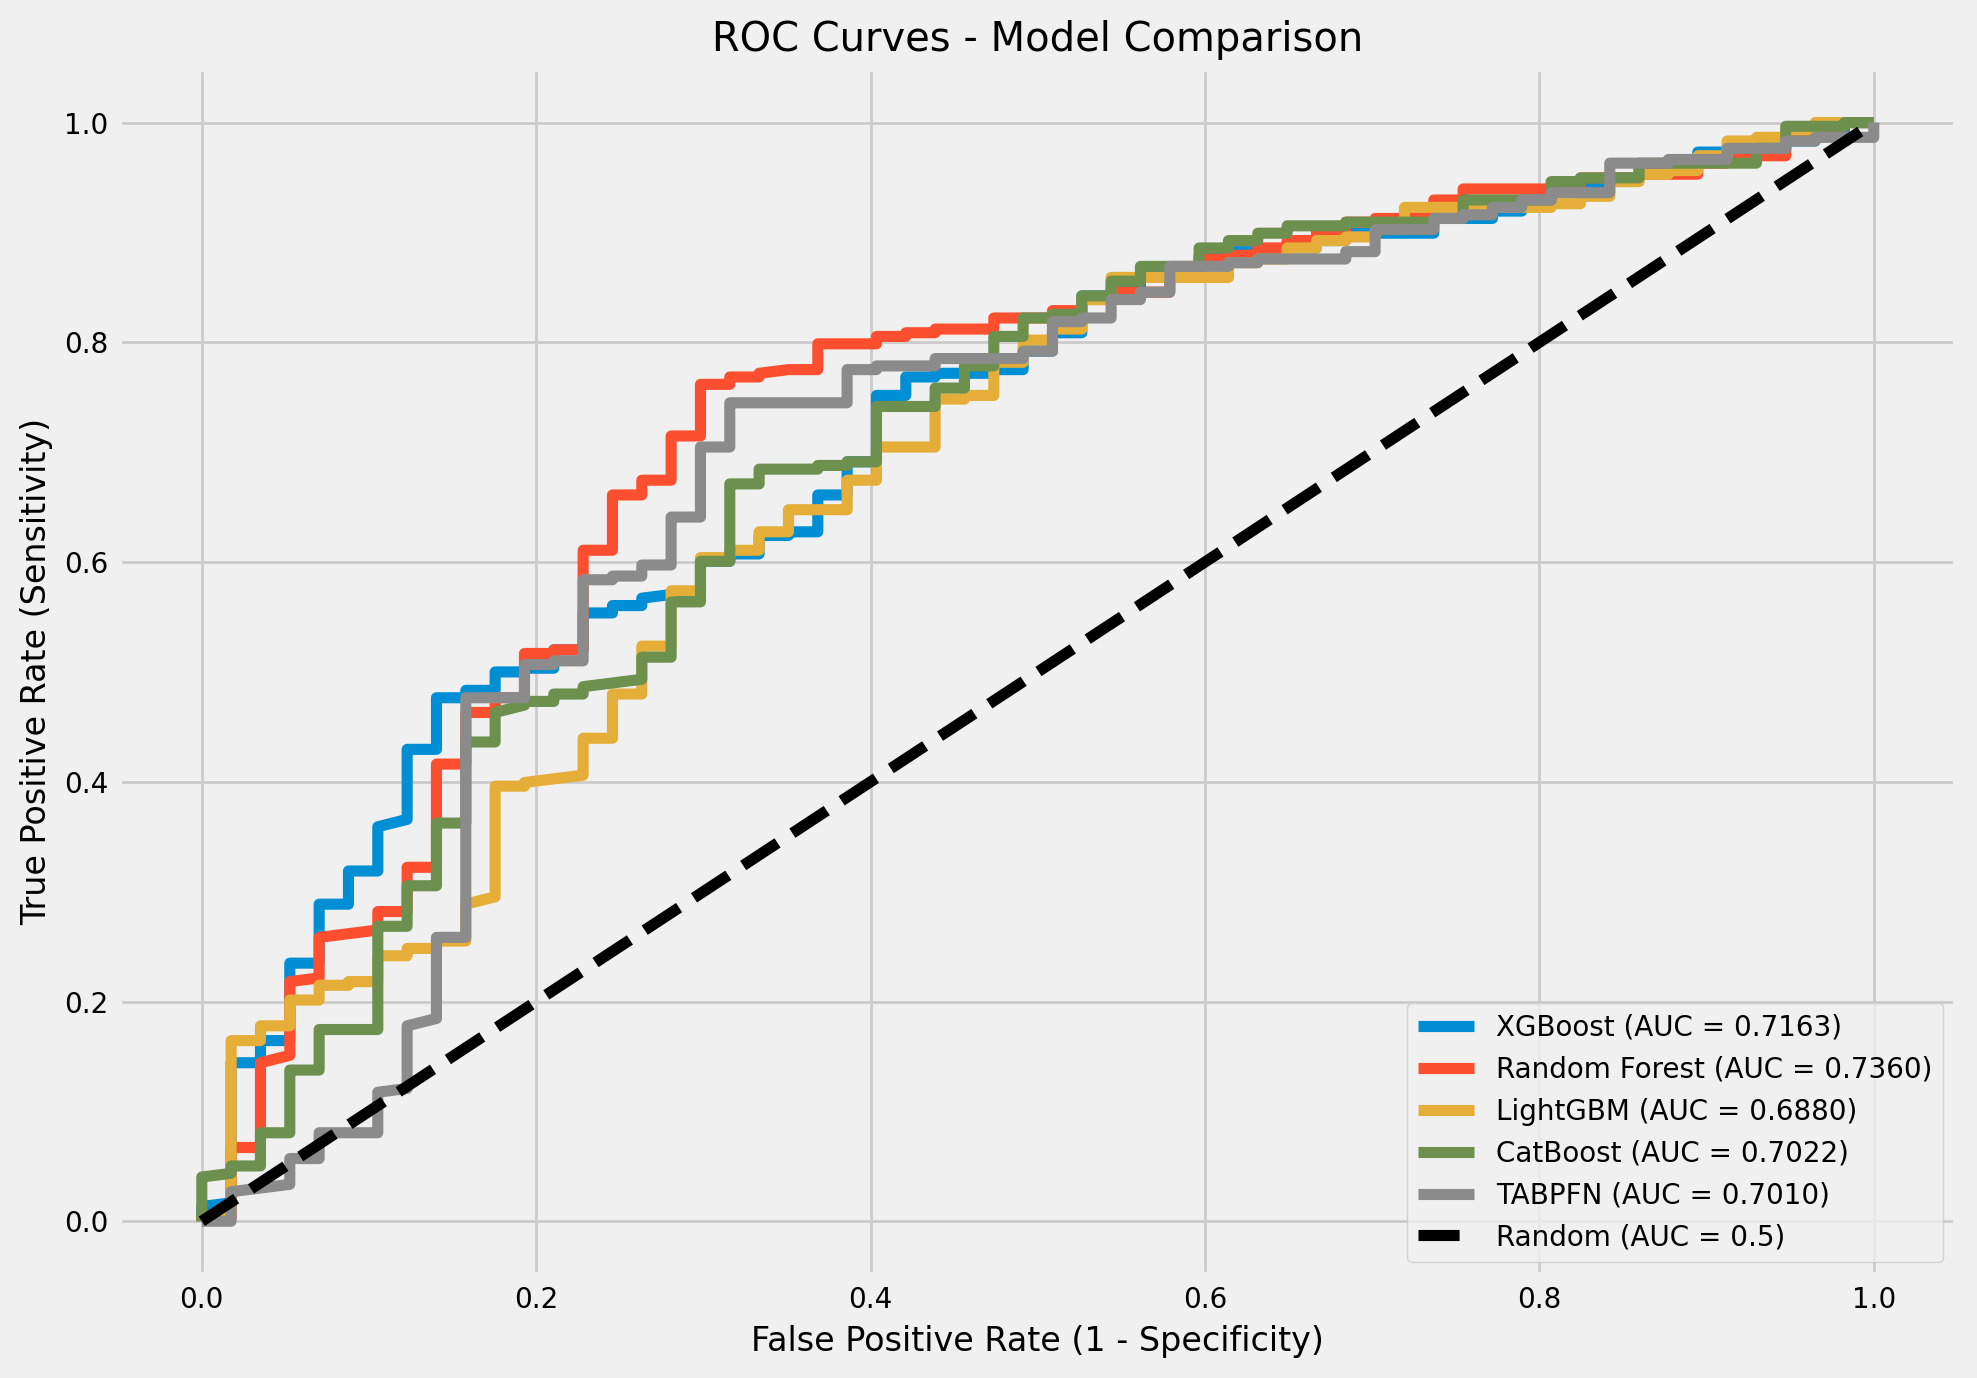

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Curvas ROC para cada modelo
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_prob_lgb)
fpr_cat, tpr_cat, _ = roc_curve(y_test, y_prob_cat)
fpr_tabpfn, tpr_tabpfn, _ = roc_curve(y_test, y_prob_tabpfn)

# Plot
plt.figure(figsize=(10, 7))
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_xgb:.4f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.4f})')
plt.plot(fpr_lgb, tpr_lgb, label=f'LightGBM (AUC = {roc_auc_lgb:.4f})')
plt.plot(fpr_cat, tpr_cat, label=f'CatBoost (AUC = {roc_auc_cat:.4f})')
plt.plot(fpr_tabpfn, tpr_tabpfn, label=f'TABPFN (AUC = {roc_auc_tabpfn:.4f})')

# Linha de referência
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5)')

# Rótulos e título
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curves - Model Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()

# Salvar a figura em .tiff com 300 DPI
plt.savefig('roc_curves_comparison.tiff', format='tiff', dpi=300)

# Mostrar o gráfico
plt.show()


In [ ]:
# Cria a figura Plotly
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=fpr_rf, y=tpr_rf,
    mode='lines',
    name=f'Random Forest (AUC = {roc_auc_rf:.4f})',
    line=dict(color='green')
))

fig.add_trace(go.Scatter(
    x=fpr_xgb, y=tpr_xgb,
    mode='lines',
    name=f'XGBoost (AUC = {roc_auc_xgb:.4f})',
    line=dict(color='orange')
))

fig.add_trace(go.Scatter(
    x=fpr_lgb, y=tpr_lgb,
    mode='lines',
    name=f'LightGBM (AUC = {roc_auc_lgb:.4f})',
    line=dict(color='blue')
))

fig.add_trace(go.Scatter(
    x=fpr_cat, y=tpr_cat,
    mode='lines',
    name=f'CatBoost (AUC = {roc_auc_cat:.4f})',
    line=dict(color='red')
))

fig.add_trace(go.Scatter(
    x=fpr_tabpfn, y=tpr_tabpfn,
    mode='lines',
    name=f'TABPFN (AUC = {roc_auc_tabpfn:.4f})',
    line=dict(color='brown')
))


# Linha de referência
fig.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1],
    mode='lines',
    line=dict(color='black', dash='dash'),
    showlegend=False
))

# Layout
fig.update_layout(
    title='ROC curve - Model Comparison',
    xaxis_title='False Positive Rate (FPR)',
    yaxis_title='True Positive Rate (TPR)',
    width=900,
    height=600
)

fig.show()

###Curva de calibraçao

In [ ]:
# Obtenção dos parametros para a curva de calibração
prob_true_rf, prob_pred_rf = calibration_curve(y_test, y_prob_rf, n_bins=20, strategy="uniform")
prob_true_xgb, prob_pred_xgb = calibration_curve(y_test, y_prob_xgb, n_bins=20, strategy="uniform")
prob_true_cat, prob_pred_cat = calibration_curve(y_test, y_prob_cat, n_bins=20, strategy="uniform")
prob_true_lgb, prob_pred_lgb = calibration_curve(y_test, y_prob_lgb, n_bins=20, strategy="uniform")
prob_true_tabpfn, prob_pred_tabpfn = calibration_curve(y_test, y_prob_tabpfn, n_bins=20, strategy="uniform")

In [ ]:
# Cria a figura Plotly
fig = go.Figure()

# Random Forest
fig.add_trace(go.Scatter(
    x=prob_pred_rf, y=prob_true_rf,
    mode='lines+markers',
    name='Random Forest',
    line=dict(color='green')
))

# XGBoost
fig.add_trace(go.Scatter(
    x=prob_pred_xgb, y=prob_true_xgb,
    mode='lines+markers',
    name='XGBoost',
    line=dict(color='orange')
))

# CatBoost
fig.add_trace(go.Scatter(
    x=prob_pred_cat, y=prob_true_cat,
    mode='lines+markers',
    name='CatBoost',
    line=dict(color='blue')
))

# LGBM
fig.add_trace(go.Scatter(
    x=prob_pred_lgb, y=prob_true_lgb,
    mode='lines+markers',
    name='LGBM',
    line=dict(color='red')
))

 #TABPFN
fig.add_trace(go.Scatter(
    x=prob_pred_tabpfn, y=prob_true_tabpfn,
    mode='lines+markers',
    name='TABPFN',
    line=dict(color='brown')
))

# Linha de referência (modelo perfeitamente calibrado)
fig.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1],
    mode='lines',
    line=dict(color='black', dash='dash'),
    showlegend=False
))

# Layout
fig.update_layout(
    title='Calibration Curve - Model Comparison',
    xaxis_title='Predicted Probability',
    yaxis_title='Observed Frequency',
    width=900,
    height=600
)

fig.show()


#4- Seleção de Variáveis e Avaliação do Melhor Modelo

---



# Seleção de Variáveis com Boruta

→ O Boruta é um algoritmo baseado em árvores que compara a importância de cada variável real com variáveis artificiais ("shadow features") criadas a partir de permutações aleatórias dos dados.

→ O algoritmo do Boruta funciona da seguinte forma:
- Cria cópias permutadas de todas as variáveis (chamadas shadow features).
- Treina um modelo de árvore com as variáveis originais + as cópias permutadas.
- Compara a importância de cada variável real com a melhor variável permutada. Ao final, a variável pode ser de três tipos:
  - Se a variável real tiver importância significativamente maior, ela é considerada Confirmada (Importante).
  - Se tiver importância significativamente menor, ela é Rejeitada (Não Importante).
  - Caso contrário, ela fica como Tentativa (Tentative) até mais iterações decidirem.

→ Documentação: https://github.com/scikit-learn-contrib/boruta_py

##Random Forest

In [ ]:
import joblib
from sklearn.metrics import roc_auc_score

# Load the best RandomForest model to ensure it's available for AUC calculation.
# Note: In the preceding cell (l2315e76mMlq), the model was incorrectly assigned
# to the variable `best_method_rf`. We'll load it into a dedicated model variable here.
rf_model = joblib.load('modelo_rf_ap_pre_selecao.pkl')

# Recalculate auc_rf using the loaded model and existing X_test, y_test variables.
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
auc_rf = roc_auc_score(y_test, y_prob_rf)

# Re-establish the correct string for `best_method_rf`.
# Based on previous outputs (e.g., cell ibZpVS_rZyNR), the best method was 'RandomSearch'.
best_method_rf_string = "RandomSearch"

print(f"✅ ROC AUC do melhor modelo ({best_method_rf_string}): {auc_rf:.4f}")

✅ ROC AUC do melhor modelo (RandomSearch): 0.7360


In [ ]:
# Criar dicionário completo com informações do modelo
best_params_rf_completo = {
    "metodo": best_method_rf_string,
    "roc_auc": auc_rf,
    "best_params": rf_model.get_params()
}

print("✅ Informações completas do modelo RF:")
print(best_params_rf_completo)

✅ Informações completas do modelo RF:
{'metodo': 'RandomSearch', 'roc_auc': np.float64(0.7359884610855999), 'best_params': {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 14, 'max_features': None, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 26, 'min_samples_split': np.float64(0.05), 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 500, 'n_jobs': -1, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}}


##• Feature selection do melhor modelo (Obrigatório para árvores e boosting)

In [ ]:
rf=rf_model

In [ ]:
pd.DataFrame({
    "variavel": X_train.columns,
    "feature_importance": rf_model.feature_importances_
}).sort_values(by="feature_importance", ascending=False)

,variavel,feature_importance
26,tratsup_at_9.0,0.273859
42,agravtabac_0.0,0.111783
9,agravalcoo_0.0,0.073241
25,tratsup_at_1.0,0.065501
1,cs_sexo_1,0.056348
39,agravdroga_0.0,0.035606
50,contato_maior5_0.0,0.033719
10,agravalcoo_1.0,0.029797
8,raiox_tora_9.0,0.028233
47,faixa_etaria2_1.0,0.024214


In [ ]:
rf_boruta = deepcopy(rf)

# Cria o BorutaPy

boruta = BorutaPy (rf_boruta,
                   n_estimators='auto',
                   alpha=0.05,
                   max_iter=100,
                   verbose=2,
                   random_state=seed)

# Fit do Boruta para encontrar as features mais relevantes
boruta.fit(X_train, y_train)

Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	60
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	60
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	60
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	60
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	60
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	60
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	60
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	0
Tentative: 	5
Rejected: 	55
Iteration: 	9 / 100
Confirmed: 	2
Tentative: 	3
Rejected: 	55
Iteration: 	10 / 100
Confirmed: 	2
Tentative: 	3
Rejected: 	55
Iteration: 	11 / 100
Confirmed: 	2
Tentative: 	3
Rejected: 	55
Iteration: 	12 / 100
Confirmed: 	3
Tentative: 	2
Rejected: 	55
Iteration: 	13 / 100
Confirmed: 	3
Tentative: 	2
Rejected: 	55
Iteration: 	14 / 100
Confirmed: 	3
Tentative: 	2
Rejected: 	55
Iteration: 	15 / 100
Confirmed: 	3
Tentative: 	2
Rejected: 	55
Iteration: 	16 / 100
Confirmed: 	3
Tentative: 	2
Rejected: 	55
I

BorutaPy(estimator=RandomForestClassifier(max_depth=14, max_features=None,
                                          min_samples_leaf=26,
                                          min_samples_split=np.float64(0.05),
                                          n_estimators=22, n_jobs=-1,
                                          random_state=RandomState(MT19937) at 0x7EC1FE869740),
         n_estimators='auto',
         random_state=RandomState(MT19937) at 0x7EC1FE869740, verbose=2)

In [ ]:
# Features confirmadas
confirmed_features = X_train.columns[boruta.support_].to_list()

# Features rejeitadas
rejected_features = X_train.columns[~(boruta.support_ | boruta.support_weak_)].to_list()

# Features tentativas
tentative_features = X_train.columns[boruta.support_weak_].to_list()

print("✅ Features confirmadas (importantes):", confirmed_features)
print("❌ Features rejeitadas:", rejected_features)
print("❓ Features tentativas:", tentative_features)

✅ Features confirmadas (importantes): ['agravalcoo_0.0', 'tratsup_at_1.0', 'tratsup_at_9.0', 'agravtabac_0.0']
❌ Features rejeitadas: ['pop', 'cs_sexo_1', 'cs_raca_1.0', 'cs_raca_2.0', 'cs_raca_4.0', 'cs_raca_9.0', 'raiox_tora_0.0', 'raiox_tora_1.0', 'raiox_tora_9.0', 'agravalcoo_1.0', 'agravalcoo_9.0', 'agravdiabe_0.0', 'agravdiabe_1.0', 'agravdiabe_9.0', 'agravdoenc_0.0', 'agravdoenc_1.0', 'agravdoenc_9.0', 'bacilosc_e_0.0', 'bacilosc_e_1.0', 'bacilosc_e_9.0', 'cultura_es_0.0', 'cultura_es_1.0', 'cultura_es_9.0', 'tratsup_at_0.0', 'pop_liber_0.0', 'pop_liber_1.0', 'pop_liber_9.0', 'pop_rua_0.0', 'pop_rua_1.0', 'pop_rua_9.0', 'pop_imig_0.0', 'pop_imig_1.0', 'pop_imig_9.0', 'benef_gov_0.0', 'benef_gov_1.0', 'benef_gov_9.0', 'agravdroga_0.0', 'agravdroga_1.0', 'agravdroga_9.0', 'agravtabac_1.0', 'agravtabac_9.0', 'front_1', 'faixa_etaria2_0.0', 'faixa_etaria2_1.0', 'faixa_etaria2_2.0', 'faixa_etaria2_3.0', 'contato_maior5_0.0', 'contato_maior5_1.0', 'contato_maior5_9.0', 'escola_faixa_0

In [ ]:
# Mostrar ranking de importância calculado pelo Boruta
feactures_ranking = pd.DataFrame({
    "variavel": X_train.columns,
    "rank": boruta.ranking_,
    "confirmada": boruta.support_,
    "tentativa": boruta.support_weak_
}).sort_values(by="rank", ascending=True)

# Print ranking
feactures_ranking.head(20)

,variavel,rank,confirmada,tentativa
9,agravalcoo_0.0,1,True,False
26,tratsup_at_9.0,1,True,False
25,tratsup_at_1.0,1,True,False
42,agravtabac_0.0,1,True,False
39,agravdroga_0.0,2,False,False
1,cs_sexo_1,3,False,False
10,agravalcoo_1.0,4,False,False
43,agravtabac_1.0,5,False,False
24,tratsup_at_0.0,6,False,False
50,contato_maior5_0.0,7,False,False


##• Retreino do melhor modelo com base nas novas features (Obrigatório para árvores e boosting)

### Retreino do Modelo

In [ ]:
# ===============================
# Seleção inicial (Boruta)
# ===============================
selected_features = confirmed_features + tentative_features

X_train_novo = X_train[selected_features].copy()
X_test_novo = X_test[selected_features].copy()

print("Shape do X_train após Boruta:", X_train_novo.shape)
print("Shape do X_test após Boruta:", X_test_novo.shape)

# ===============================
# Verificação automática
# ===============================
if X_train_novo.shape[1] < 10:
    print("\n⚠ Menos de 10 features selecionadas. Usando Top 20 do ranking.")

    # Selecionar top 20 do ranking
    top_20_features = feactures_ranking['variavel'].head(20).tolist()

    X_train_novo = X_train[top_20_features].copy()
    X_test_novo = X_test[top_20_features].copy()

    print("Novo shape com Top 20 features:")
    print("Shape do X_train:", X_train_novo.shape)
    print("Shape do X_test:", X_test_novo.shape)

else:
    print("\n✅ Mantendo features selecionadas pelo Boruta.")

Shape do X_train após Boruta: (788, 4)
Shape do X_test após Boruta: (355, 4)

⚠ Menos de 10 features selecionadas. Usando Top 20 do ranking.
Novo shape com Top 20 features:
Shape do X_train: (788, 20)
Shape do X_test: (355, 20)


In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.metrics import roc_auc_score

# ======================================
# SELEÇÃO AUTOMÁTICA DO MÉTODO
# ======================================

# Use best_method_rf_string for comparison, as it holds the method name
if best_method_rf_string == "RandomSearch":

    print("\n🚀 Executando RANDOM SEARCH...")

    rf_dict = {
        'n_estimators': np.arange(200, 501, 100),
        'max_depth': np.arange(5, 15, 1),
        'min_samples_split': np.arange(0.01, 0.06, 0.01),
        'min_samples_leaf': [5, 10, 26],
        'max_features': [None, 'sqrt', 'log2']
    }

    rf_base = RandomForestClassifier(
        random_state=seed,
        n_jobs=-1
    )

    rf_novo = RandomizedSearchCV(
        estimator=rf_base,
        param_distributions=rf_dict,
        scoring="roc_auc",
        cv=5,
        n_iter=20,
        n_jobs=-1,
        random_state=seed
    )

    rf_novo.fit(X_train_novo, y_train)

    best_params_rf_novo = rf_novo.best_params_
    print("Melhores hiperparâmetros:", best_params_rf_novo)

    rf_novo = rf_novo.best_estimator_

# The redundant 'elif best_method_rf == "RandomSearch"' block has been removed.
# You can add other methods like 'Optuna' or 'Hyperopt' here if needed,
# checking against 'best_method_rf_string'.

# ======================================
# TREINAMENTO FINAL
# ======================================

rf_novo.fit(X_train_novo, y_train)

y_prob_rf = rf_novo.predict_proba(X_test_novo)[:, 1]
auc_rf = roc_auc_score(y_test, y_prob_rf)

print(f"\n✅ ROC AUC do melhor modelo ({best_method_rf_string}): {auc_rf:.4f}")


🚀 Executando RANDOM SEARCH...
Melhores hiperparâmetros: {'n_estimators': np.int64(500), 'min_samples_split': np.float64(0.05), 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': np.int64(14)}

✅ ROC AUC do melhor modelo (RandomSearch): 0.7143


###Modelos comparados original vs boruta

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
import pandas as pd

# ======================================
# USAR O MODELO ORIGINAL JÁ TREINADO
# ======================================
rf_original = rf
# Probabilidades modelo original
y_prob_original = rf_original.predict_proba(X_test)[:, 1]

# AUC modelo original
auc_original = roc_auc_score(y_test, y_prob_original)


# ======================================
# TREINAR MODELO NA BASE BORUTA
# ======================================

rf_boruta = RandomForestClassifier(
    **best_params_rf_novo,
    random_state=seed,
    n_jobs=-1
)

rf_boruta.fit(X_train_novo, y_train)

y_prob_boruta = rf_boruta.predict_proba(X_test_novo)[:, 1]
auc_boruta = roc_auc_score(y_test, y_prob_boruta)


# ======================================
# COMPARAÇÃO FINAL
# ======================================

print("\n==============================")
print("📊 COMPARAÇÃO FINAL DOS MODELOS (RandomForest)")
print("=============================")
print(f"AUC - Base Completa  : {auc_original:.4f}")
print(f"AUC - Após Boruta    : {auc_boruta:.4f}")

if auc_boruta > auc_original:
    print("\n🏆 Melhor modelo: BORUTA")
elif auc_original > auc_boruta:
    print("\n🏆 Melhor modelo: BASE COMPLETA")
else:
    print("\n🤝 Empate técnico")


# ======================================
# TABELA RESUMO
# ======================================

df_comparacao = pd.DataFrame({
    "Modelo": ["Base Completa", "Após Boruta"],
    "AUC": [auc_original, auc_boruta],
    "N_Features": [X_train.shape[1], X_train_novo.shape[1]]
})

print("\nResumo Final:")
print(df_comparacao)


📊 COMPARAÇÃO FINAL DOS MODELOS (RandomForest)
AUC - Base Completa  : 0.7360
AUC - Após Boruta    : 0.7143

🏆 Melhor modelo: BASE COMPLETA

Resumo Final:
          Modelo       AUC  N_Features
0  Base Completa  0.735988          60
1    Após Boruta  0.714265          20


##• Comparação da performance com e sem feature selection (Obrigatório para árvores e boosting)

#### Comparação da Performance dos Modelos - curva roc

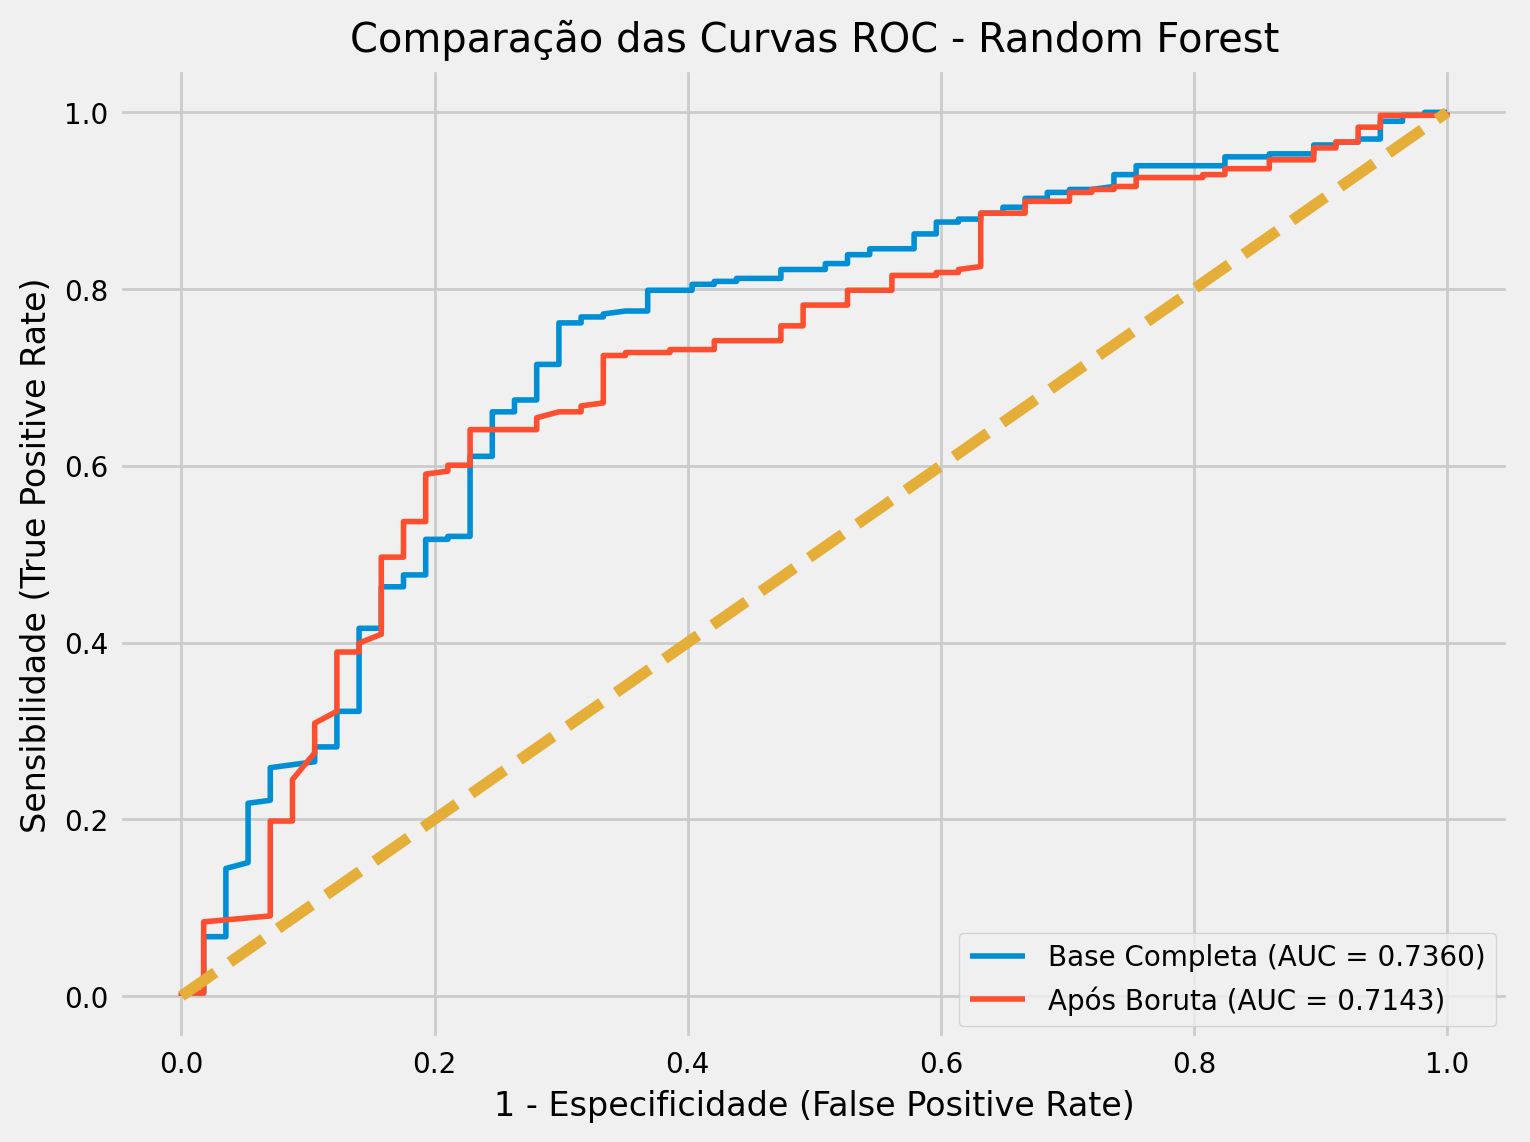

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# ======================================
# CURVAS ROC
# ======================================

fpr_original, tpr_original, _ = roc_curve(y_test, y_prob_original)
fpr_boruta, tpr_boruta, _ = roc_curve(y_test, y_prob_boruta)

# ======================================
# PLOT
# ======================================

plt.figure(figsize=(8,6))

plt.plot(
    fpr_original,
    tpr_original,
    label=f'Base Completa (AUC = {auc_original:.4f})',
    linewidth=2
)

plt.plot(
    fpr_boruta,
    tpr_boruta,
    label=f'Após Boruta (AUC = {auc_boruta:.4f})',
    linewidth=2
)

# Linha aleatória
plt.plot([0,1], [0,1], linestyle='--')

# Configurações
plt.xlabel('1 - Especificidade (False Positive Rate)')
plt.ylabel('Sensibilidade (True Positive Rate)')
plt.title('Comparação das Curvas ROC - Random Forest')
plt.legend(loc='lower right')

plt.grid(True)
plt.show()

#### Comparação da Calibração do Modelo

In [ ]:
import plotly.graph_objects as go
from sklearn.calibration import calibration_curve

# Probabilities
y_prob_rf = rf.predict_proba(X_test)[:, 1]
y_prob_rf_novo = rf_novo.predict_proba(X_test_novo)[:, 1] # Changed X_test_novo to X_test_rf_boruta

# Calibration curves
prob_true_rf, prob_pred_rf = calibration_curve(y_test, y_prob_rf, n_bins=10, strategy="uniform")
prob_true_rf_novo, prob_pred_rf_novo = calibration_curve(y_test, y_prob_rf_novo, n_bins=10, strategy="uniform")

# Creating the interactive figure
fig = go.Figure()

# Perfect line
fig.add_trace(go.Scatter(
    x=[0,1], y=[0,1],
    mode='lines',
    name='Perfeita',
    line=dict(color='gray', dash='dash')
))

# Original model
fig.add_trace(go.Scatter(
    x=prob_pred_rf, y=prob_true_rf,
    mode='lines+markers',
    name='RF original',
    line=dict(color='blue')
))

# Model with Boruta
fig.add_trace(go.Scatter(
    x=prob_pred_rf_novo, y=prob_true_rf_novo,
    mode='lines+markers',
    name='RF com Boruta',
    line=dict(color='green')
))

# Layout
fig.update_layout(
    title='Curvas de Calibração (Interativo)',
    xaxis_title='Probabilidade prevista',
    yaxis_title='Frequência observada',
    legend=dict(x=0.65, y=0.05),
    width=800,
    height=600
)

fig.show()

In [ ]:
#Nenhum dos dois modelos previu probabilidades abaixo de ~0.58.

##XGBoost

In [ ]:
import joblib
from sklearn.metrics import roc_auc_score

# Load the best RandomForest model to ensure it's available for AUC calculation.
# Note: In the preceding cell (l2315e76mMlq), the model was incorrectly assigned
# to the variable `best_method_rf`. We'll load it into a dedicated model variable here.
xgb_rs = joblib.load('modelo_xgb_ap_pre_selecao.pkl')


In [ ]:
xgb = xgb_rs
# Generate predictions and probabilities
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

# Métricas
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

# Impressão
print(f'xgbBoost - ROC AUC: {auc_xgb:.4f}')

xgbBoost - ROC AUC: 0.7163


In [ ]:
auc_xgb_rs = roc_auc_score(y_test, y_prob_xgb)
params_xgb_rs = xgb_rs.get_params()
best_params_xgb_completo = params_xgb_rs

In [ ]:
best_model_name = 'XGBoost'
best_method_xgb = 'RandomSearch'

print(f"\n✅ Melhores hiperparâmetros do modelo {best_model_name} ({best_method_xgb}):")

for param, value in best_params_xgb_completo.items():
    print(f"{param}: {value}")


✅ Melhores hiperparâmetros do modelo XGBoost (RandomSearch):
objective: binary:logistic
base_score: None
booster: None
callbacks: None
colsample_bylevel: None
colsample_bynode: None
colsample_bytree: 0.6
device: None
early_stopping_rounds: None
enable_categorical: False
eval_metric: None
feature_types: None
feature_weights: None
gamma: 0.3
grow_policy: None
importance_type: None
interaction_constraints: None
learning_rate: 0.07356422544596414
max_bin: None
max_cat_threshold: None
max_cat_to_onehot: None
max_delta_step: None
max_depth: 8
max_leaves: None
min_child_weight: None
missing: nan
monotone_constraints: None
multi_strategy: None
n_estimators: 200
n_jobs: None
num_parallel_tree: None
random_state: 42
reg_alpha: 0.001
reg_lambda: 1.0
sampling_method: None
scale_pos_weight: None
subsample: 1.0
tree_method: None
validate_parameters: None
verbosity: None


##• Feature selection do melhor modelo (Obrigatório para árvores e boosting)

In [ ]:
pd.DataFrame({
    "variavel": X_train.columns,
    "feature_importance": xgb.feature_importances_
}).sort_values(by="feature_importance", ascending=False)

,variavel,feature_importance
26,tratsup_at_9.0,0.087098
42,agravtabac_0.0,0.039438
31,pop_rua_1.0,0.036408
9,agravalcoo_0.0,0.033850
25,tratsup_at_1.0,0.029549
28,pop_liber_1.0,0.025476
2,cs_raca_1.0,0.024964
24,tratsup_at_0.0,0.024778
46,faixa_etaria2_0.0,0.024462
10,agravalcoo_1.0,0.023572


In [ ]:
xgb_boruta = deepcopy(xgb)

# Cria o BorutaPy

boruta = BorutaPy (xgb_boruta,
                   n_estimators='auto',
                   alpha=0.05,
                   max_iter=100,
                   verbose=2,
                   random_state=seed)

# Fit do Boruta para encontrar as features mais relevantes
boruta.fit(X_train, y_train)

Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	60
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	60
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	60
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	60
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	60
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	60
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	60
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	0
Tentative: 	17
Rejected: 	43
Iteration: 	9 / 100
Confirmed: 	2
Tentative: 	15
Rejected: 	43
Iteration: 	10 / 100
Confirmed: 	2
Tentative: 	15
Rejected: 	43
Iteration: 	11 / 100
Confirmed: 	2
Tentative: 	15
Rejected: 	43
Iteration: 	12 / 100
Confirmed: 	2
Tentative: 	11
Rejected: 	47
Iteration: 	13 / 100
Confirmed: 	2
Tentative: 	11
Rejected: 	47
Iteration: 	14 / 100
Confirmed: 	2
Tentative: 	11
Rejected: 	47
Iteration: 	15 / 100
Confirmed: 	2
Tentative: 	11
Rejected: 	47
Iteration: 	16 / 100
Confirmed: 	3
Tentative: 	10
Reject

BorutaPy(estimator=XGBClassifier(base_score=None, booster=None, callbacks=None,
                                 colsample_bylevel=None, colsample_bynode=None,
                                 colsample_bytree=np.float64(0.6), device=None,
                                 early_stopping_rounds=None,
                                 enable_categorical=False, eval_metric=None,
                                 feature_types=None, feature_weights=None,
                                 gamma=np.float64(0.3), grow_policy=None,
                                 importance_type=None,
                                 interaction_co...
                                 learning_rate=np.float64(0.07356422544596414),
                                 max_bin=None, max_cat_threshold=None,
                                 max_cat_to_onehot=None, max_delta_step=None,
                                 max_depth=np.int64(8), max_leaves=None,
                                 min_child_weight=None, missing=nan,
                                 monotone_constraints=None, multi_strategy=None,
                                 n_estimators=55, n_jobs=None,
                                 num_parallel_tree=None, ...),
         n_estimators='auto',
         random_state=RandomState(MT19937) at 0x7EC21F920540, verbose=2)

In [ ]:
# Features confirmadas
confirmed_features = X_train.columns[boruta.support_].to_list()

# Features rejeitadas
rejected_features = X_train.columns[~(boruta.support_ | boruta.support_weak_)].to_list()

# Features tentativas
tentative_features = X_train.columns[boruta.support_weak_].to_list()

print("✅ Features confirmadas (importantes):", confirmed_features)
print("❌ Features rejeitadas:", rejected_features)
print("❓ Features tentativas:", tentative_features)

✅ Features confirmadas (importantes): ['agravalcoo_0.0', 'tratsup_at_1.0', 'tratsup_at_9.0', 'pop_rua_1.0', 'agravtabac_0.0', 'front_1']
❌ Features rejeitadas: ['pop', 'cs_sexo_1', 'cs_raca_1.0', 'cs_raca_2.0', 'cs_raca_4.0', 'cs_raca_9.0', 'raiox_tora_0.0', 'raiox_tora_1.0', 'raiox_tora_9.0', 'agravalcoo_9.0', 'agravdiabe_0.0', 'agravdiabe_1.0', 'agravdiabe_9.0', 'agravdoenc_0.0', 'agravdoenc_1.0', 'agravdoenc_9.0', 'bacilosc_e_0.0', 'bacilosc_e_1.0', 'bacilosc_e_9.0', 'cultura_es_0.0', 'cultura_es_1.0', 'cultura_es_9.0', 'tratsup_at_0.0', 'pop_liber_0.0', 'pop_liber_9.0', 'pop_rua_0.0', 'pop_rua_9.0', 'pop_imig_0.0', 'pop_imig_1.0', 'pop_imig_9.0', 'benef_gov_0.0', 'benef_gov_1.0', 'benef_gov_9.0', 'agravdroga_1.0', 'agravdroga_9.0', 'agravtabac_1.0', 'agravtabac_9.0', 'faixa_etaria2_0.0', 'faixa_etaria2_1.0', 'faixa_etaria2_2.0', 'faixa_etaria2_3.0', 'contato_maior5_0.0', 'contato_maior5_1.0', 'contato_maior5_9.0', 'escola_faixa_0.0', 'escola_faixa_1.0', 'escola_faixa_9.0', 'escola_

In [ ]:
# Mostrar ranking de importância calculado pelo Boruta
feactures_ranking = pd.DataFrame({
    "variavel": X_train.columns,
    "rank": boruta.ranking_,
    "confirmada": boruta.support_,
    "tentativa": boruta.support_weak_
}).sort_values(by="rank", ascending=True)

# Print ranking
feactures_ranking.head(20)

,variavel,rank,confirmada,tentativa
9,agravalcoo_0.0,1,True,False
25,tratsup_at_1.0,1,True,False
31,pop_rua_1.0,1,True,False
26,tratsup_at_9.0,1,True,False
42,agravtabac_0.0,1,True,False
45,front_1,1,True,False
28,pop_liber_1.0,2,False,True
10,agravalcoo_1.0,2,False,True
39,agravdroga_0.0,2,False,True
46,faixa_etaria2_0.0,3,False,False


##• Retreino do melhor modelo com base nas novas features (Obrigatório para árvores e boosting)

### Retreino do Modelo

In [ ]:
# ===============================
# Seleção inicial (Boruta)
# ===============================
selected_features = confirmed_features + tentative_features

X_train_novo = X_train[selected_features].copy()
X_test_novo = X_test[selected_features].copy()

print("Shape do X_train após Boruta:", X_train_novo.shape)
print("Shape do X_test após Boruta:", X_test_novo.shape)

# ===============================
# Verificação automática
# ===============================
if X_train_novo.shape[1] < 10:
    print("\n⚠ Menos de 10 features selecionadas. Usando Top 20 do ranking.")

    # Selecionar top 20 do ranking
    top_20_features = feactures_ranking['variavel'].head(20).tolist()

    X_train_novo = X_train[top_20_features].copy()
    X_test_novo = X_test[top_20_features].copy()

    print("Novo shape com Top 20 features:")
    print("Shape do X_train:", X_train_novo.shape)
    print("Shape do X_test:", X_test_novo.shape)

else:
    print("\n✅ Mantendo features selecionadas pelo Boruta.")

Shape do X_train após Boruta: (788, 9)
Shape do X_test após Boruta: (355, 9)

⚠ Menos de 10 features selecionadas. Usando Top 20 do ranking.
Novo shape com Top 20 features:
Shape do X_train: (788, 20)
Shape do X_test: (355, 20)


In [ ]:
print(f"✅ ROC AUC do melhor modelo ({best_method_xgb}): {auc_xgb:.4f}")

✅ ROC AUC do melhor modelo (RandomSearch): 0.7163


In [ ]:
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.metrics import roc_auc_score

# ======================================
# SELEÇÃO AUTOMÁTICA DO MÉTODO
# ======================================



# ======================================

if best_method_xgb == "RandomSearch":

    print("\n🚀 Executando RANDOM SEARCH (XGBoost)...")

    xgb_dict = {
    'n_estimators': np.arange(200, 501, 100),           # número de árvores, de 100 a 500 com passo de 100
    'max_depth': np.arange(3, 11, 1),                   # profundidade máxima da árvore, de 3 a 10
    'learning_rate': np.logspace(-2, -0.7, 4),          # taxa de aprendizado, de 0.01 a 0.2 em escala logarítmica
    'subsample': np.linspace(0.6, 1.0, 3),              # proporção de amostras usadas por árvore
    'colsample_bytree': np.linspace(0.6, 1.0, 3),       # proporção de features usadas por árvore
    'gamma': np.linspace(0, 0.3, 4),                    # regularização por redução mínima da perda
    'reg_alpha': np.logspace(-3, 0, 4),                 # regularização L1, de 0.001 a 1
    'reg_lambda': np.linspace(1, 2, 3)                  # regularização L2, de 1 a 2
    }

    xgb_base = XGBClassifier(
        random_state=seed,
        eval_metric="logloss",
        n_jobs=-1
    )

    xgb_random_search = RandomizedSearchCV( # Renamed xgb_novo to xgb_random_search for clarity
        estimator=xgb_base,
        param_distributions=xgb_dict,
        scoring="roc_auc",
        cv=5,
        n_iter=20,
        n_jobs=-1,
        random_state=seed
    )

    xgb_random_search.fit(X_train_novo, y_train)

    best_params_xgb_novo = xgb_random_search.best_params_
    print("Melhores hiperparâmetros:", best_params_xgb_novo)

    xgb_novo = xgb_random_search.best_estimator_


# ======================================
# TREINAMENTO FINAL
# ======================================

xgb_novo.fit(X_train_novo, y_train)

y_prob_xgb = xgb_novo.predict_proba(X_test_novo)[:, 1]
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print(f"\n✅ ROC AUC do melhor modelo ({best_method_xgb}): {auc_xgb:.4f}")


🚀 Executando RANDOM SEARCH (XGBoost)...
Melhores hiperparâmetros: {'subsample': np.float64(1.0), 'reg_lambda': np.float64(1.0), 'reg_alpha': np.float64(0.001), 'n_estimators': np.int64(200), 'max_depth': np.int64(8), 'learning_rate': np.float64(0.07356422544596414), 'gamma': np.float64(0.3), 'colsample_bytree': np.float64(0.6)}

✅ ROC AUC do melhor modelo (RandomSearch): 0.6910


###Modelos comparados original vs boruta

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
import pandas as pd

# ======================================
# USAR O MODELO ORIGINAL JÁ TREINADO
# ======================================

y_prob_original = xgb.predict_proba(X_test)[:, 1]
auc_original = roc_auc_score(y_test, y_prob_original)


# ======================================
# TREINAR MODELO NA BASE BORUTA
# ======================================

xgb_boruta = XGBClassifier(
    **best_params_xgb_novo,
    random_state=seed,
    eval_metric="logloss",
    n_jobs=-1
)

xgb_boruta.fit(X_train_novo, y_train)

y_prob_boruta = xgb_boruta.predict_proba(X_test_novo)[:, 1]
auc_boruta = roc_auc_score(y_test, y_prob_boruta)


# ======================================
# COMPARAÇÃO FINAL
# ======================================

print("\n==============================")
print("📊 COMPARAÇÃO FINAL DOS MODELOS (XGBoost)")
print("==============================")
print(f"AUC - Base Completa  : {auc_original:.4f}")
print(f"AUC - Após Boruta    : {auc_boruta:.4f}")

if auc_boruta > auc_original:
    print("\n🏆 Melhor modelo: BORUTA")
elif auc_original > auc_boruta:
    print("\n🏆 Melhor modelo: BASE COMPLETA")
else:
    print("\n🤝 Empate técnico")


# ======================================
# TABELA RESUMO
# ======================================

df_comparacao = pd.DataFrame({
    "Modelo": ["Base Completa", "Após Boruta"],
    "AUC": [auc_original, auc_boruta],
    "N_Features": [X_train.shape[1], X_train_novo.shape[1]]
})

print("\nResumo Final:")
print(df_comparacao)


📊 COMPARAÇÃO FINAL DOS MODELOS (XGBoost)
AUC - Base Completa  : 0.7163
AUC - Após Boruta    : 0.6910

🏆 Melhor modelo: BASE COMPLETA

Resumo Final:
          Modelo       AUC  N_Features
0  Base Completa  0.716266          60
1    Após Boruta  0.690981          20


##• Comparação da performance com e sem feature selection (Obrigatório para árvores e boosting)

#### Comparação da Performance dos Modelos - curva roc

In [ ]:
import plotly.graph_objects as go
from sklearn.metrics import roc_curve, auc

# Probabilidades de cura
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
y_prob_xgb_novo = xgb_novo.predict_proba(X_test_novo)[:, 1]

# Curva ROC - Modelo original
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

# Curva ROC - Modelo com novas features
fpr_xgb_novo, tpr_xgb_novo, _ = roc_curve(y_test, y_prob_xgb_novo)
roc_auc_xgb_novo = auc(fpr_xgb_novo, tpr_xgb_novo)

# Criando a figura interativa
fig = go.Figure()

# Modelo original
fig.add_trace(go.Scatter(
    x=fpr_xgb, y=tpr_xgb,
    mode='lines',
    name=f'Modelo original (AUC = {roc_auc_xgb:.4f})',
    line=dict(color='blue')
))

# Modelo novo
fig.add_trace(go.Scatter(
    x=fpr_xgb_novo, y=tpr_xgb_novo,
    mode='lines',
    name=f'Modelo com boruta (AUC = {roc_auc_xgb_novo:.4f})',
    line=dict(color='green')
))

# Linha aleatória (baseline)
fig.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1],
    mode='lines',
    name='Aleatório (AUC = 0.50)',
    line=dict(color='gray', dash='dash')
))

# Layout
fig.update_layout(
    title='Comparação das Curvas ROC (Interativo)',
    xaxis_title='Taxa de Falsos Positivos (1 - Especificidade)',
    yaxis_title='Taxa de Verdadeiros Positivos (Sensibilidade)',
    legend=dict(x=0.65, y=0.05),
    width=800,
    height=600
)

fig.show()


####Comparação da Calibração do Modelo

In [ ]:
import plotly.graph_objects as go
from sklearn.calibration import calibration_curve

# Probabilidades de cura
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
y_prob_xgb_novo = xgb_novo.predict_proba(X_test_novo)[:, 1]

# Curvas de calibração
prob_true_xgb, prob_pred_xgb = calibration_curve(y_test, y_prob_xgb, n_bins=10, strategy="uniform")
prob_true_xgb_novo, prob_pred_xgb_novo = calibration_curve(y_test, y_prob_xgb_novo, n_bins=10, strategy="uniform")

# Criando a figura interativa
fig = go.Figure()

# Linha ideal
fig.add_trace(go.Scatter(
    x=[0,1], y=[0,1],
    mode='lines',
    name='Perfeita',
    line=dict(color='gray', dash='dash')
))

# Modelo original
fig.add_trace(go.Scatter(
    x=prob_pred_xgb, y=prob_true_xgb,
    mode='lines+markers',
    name='XGB original',
    line=dict(color='blue')
))

# Modelo com Boruta
fig.add_trace(go.Scatter(
    x=prob_pred_xgb_novo, y=prob_true_xgb_novo,
    mode='lines+markers',
    name='XGB com Boruta',
    line=dict(color='green')
))

# Layout
fig.update_layout(
    title='Curvas de Calibração (Interativo)',
    xaxis_title='Probabilidade prevista',
    yaxis_title='Frequência observada',
    legend=dict(x=0.65, y=0.05),
    width=800,
    height=600
)

fig.show()


##LGBM

In [ ]:
import joblib
from sklearn.metrics import roc_auc_score

# Load the best RandomForest model to ensure it's available for AUC calculation.
# Note: In the preceding cell (l2315e76mMlq), the model was incorrectly assigned
# to the variable `best_method_rf`. We'll load it into a dedicated model variable here.
lgb_rs = joblib.load('modelo_lgb_ap_pre_selecao.pkl')


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Ensure lgb is correctly assigned from the loaded lgb_rs object
lgb = lgb_rs

# Probabilidades
y_prob_lgb = lgb.predict_proba(X_test)[:, 1]

# Aplica o threshold
threshold = 0.5
y_pred_lgb = (y_prob_lgb >= threshold).astype(int)

# Métricas
auc_lgb = roc_auc_score(y_test, y_prob_lgb)  # Continua usando probabilidade para o AUC

# Impressão
print(f'lgb - ROC AUC: {auc_lgb:.4f}')

[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
lgb - ROC AUC: 0.6880


In [ ]:
auc_lgb_rs = roc_auc_score(y_test, y_prob_lgb)
params_lgb_rs = lgb_rs.get_params()

In [ ]:
best_model_name = 'LightGBM'
best_method_lgb = 'RandomSearch'
print(f"\n✅ Melhores hiperparâmetros do modelo {best_model_name} ({best_method_lgb}):")

best_params_lgb_completo = params_lgb_rs

for param, value in best_params_lgb_completo.items():
    print(f"{param}: {value}")


✅ Melhores hiperparâmetros do modelo LightGBM (RandomSearch):
boosting_type: gbdt
class_weight: None
colsample_bytree: 1.0
importance_type: split
learning_rate: 0.02712272579332028
max_depth: 5
min_child_samples: 20
min_child_weight: 0.001
min_split_gain: 0.0
n_estimators: 200
n_jobs: None
num_leaves: 31
objective: None
random_state: 42
reg_alpha: 0.1
reg_lambda: 1.0
subsample: 1.0
subsample_for_bin: 200000
subsample_freq: 0
min_data_in_leaf: 10


##• Feature selection do melhor modelo (Obrigatório para árvores e boosting)

In [ ]:
pd.DataFrame({
    "variavel": X_train.columns,
    "feature_importance": lgb.feature_importances_
}).sort_values(by="feature_importance", ascending=False)

,variavel,feature_importance
0,pop,372
43,agravtabac_1.0,96
51,contato_maior5_1.0,90
26,tratsup_at_9.0,90
28,pop_liber_1.0,81
10,agravalcoo_1.0,78
19,bacilosc_e_1.0,76
2,cs_raca_1.0,75
42,agravtabac_0.0,75
8,raiox_tora_9.0,74


In [ ]:
lgb_boruta = deepcopy(lgb)

# Cria o BorutaPy

boruta = BorutaPy (lgb_boruta,
                   n_estimators='auto',
                   alpha=0.10,
                   max_iter=500,
                   verbose=2,
                   random_state=seed)

# Fit do Boruta para encontrar as features mais relevantes
boruta.fit(X_train, y_train)

[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Info] Number of positive: 682, number of negative: 106
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001024 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 246
[LightGBM] [Info] Number of data points in the train set: 788, number of used features: 112
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.865482 -> initscore=1.861591
[LightGBM] [Info] Start training from score 1.861591
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

BorutaPy(alpha=0.1,
         estimator=LGBMClassifier(colsample_bytree=np.float64(1.0),
                                  learning_rate=np.float64(0.02712272579332028),
                                  max_depth=np.int64(5), min_data_in_leaf=10,
                                  n_estimators=28, random_state=4959,
                                  reg_alpha=np.float64(0.1),
                                  reg_lambda=np.float64(1.0),
                                  subsample=np.float64(1.0)),
         max_iter=500, n_estimators='auto',
         random_state=RandomState(MT19937) at 0x7EC20C193940, verbose=2)

In [ ]:
# Features confirmadas
confirmed_features = X_train.columns[boruta.support_].to_list()

# Features rejeitadas
rejected_features = X_train.columns[~(boruta.support_ | boruta.support_weak_)].to_list()

# Features tentativas
tentative_features = X_train.columns[boruta.support_weak_].to_list()

print("✅ Features confirmadas (importantes):", confirmed_features)
print("❌ Features rejeitadas:", rejected_features)
print("❓ Features tentativas:", tentative_features)

✅ Features confirmadas (importantes): ['pop']
❌ Features rejeitadas: ['cs_sexo_1', 'cs_raca_1.0', 'cs_raca_2.0', 'cs_raca_4.0', 'cs_raca_9.0', 'raiox_tora_0.0', 'raiox_tora_1.0', 'raiox_tora_9.0', 'agravalcoo_0.0', 'agravalcoo_1.0', 'agravalcoo_9.0', 'agravdiabe_0.0', 'agravdiabe_1.0', 'agravdiabe_9.0', 'agravdoenc_0.0', 'agravdoenc_1.0', 'agravdoenc_9.0', 'bacilosc_e_0.0', 'bacilosc_e_1.0', 'bacilosc_e_9.0', 'cultura_es_0.0', 'cultura_es_1.0', 'cultura_es_9.0', 'tratsup_at_0.0', 'tratsup_at_1.0', 'tratsup_at_9.0', 'pop_liber_0.0', 'pop_liber_1.0', 'pop_liber_9.0', 'pop_rua_0.0', 'pop_rua_1.0', 'pop_rua_9.0', 'pop_imig_0.0', 'pop_imig_1.0', 'pop_imig_9.0', 'benef_gov_0.0', 'benef_gov_1.0', 'benef_gov_9.0', 'agravdroga_0.0', 'agravdroga_1.0', 'agravdroga_9.0', 'agravtabac_0.0', 'agravtabac_1.0', 'agravtabac_9.0', 'front_1', 'faixa_etaria2_0.0', 'faixa_etaria2_1.0', 'faixa_etaria2_2.0', 'faixa_etaria2_3.0', 'contato_maior5_0.0', 'contato_maior5_1.0', 'contato_maior5_9.0', 'escola_faixa_0

In [ ]:
# Mostrar ranking de importância calculado pelo Boruta
feactures_ranking = pd.DataFrame({
    "variavel": X_train.columns,
    "rank": boruta.ranking_,
    "confirmada": boruta.support_,
    "tentativa": boruta.support_weak_
}).sort_values(by="rank", ascending=True)

# Print ranking
feactures_ranking.head(20)

,variavel,rank,confirmada,tentativa
0,pop,1,True,False
26,tratsup_at_9.0,2,False,False
25,tratsup_at_1.0,3,False,False
9,agravalcoo_0.0,4,False,False
19,bacilosc_e_1.0,5,False,False
28,pop_liber_1.0,6,False,False
55,escola_faixa_9.0,7,False,False
2,cs_raca_1.0,8,False,False
42,agravtabac_0.0,9,False,False
1,cs_sexo_1,10,False,False


##• Retreino do melhor modelo com base nas novas features (Obrigatório para árvores e boosting)

In [ ]:
# ===============================
# Seleção inicial (Boruta)
# ===============================
selected_features = confirmed_features + tentative_features

X_train_novo = X_train[selected_features].copy()
X_test_novo = X_test[selected_features].copy()

print("Shape do X_train após Boruta:", X_train_novo.shape)
print("Shape do X_test após Boruta:", X_test_novo.shape)

# ===============================
# Verificação automática
# ===============================
if X_train_novo.shape[1] < 10:
    print("\n⚠ Menos de 10 features selecionadas. Usando Top 20 do ranking.")

    # Selecionar top 20 do ranking
    top_20_features = feactures_ranking['variavel'].head(20).tolist()

    X_train_novo = X_train[top_20_features].copy()
    X_test_novo = X_test[top_20_features].copy()

    print("Novo shape com Top 20 features:")
    print("Shape do X_train:", X_train_novo.shape)
    print("Shape do X_test:", X_test_novo.shape)

else:
    print("\n✅ Mantendo features selecionadas pelo Boruta.")

Shape do X_train após Boruta: (788, 1)
Shape do X_test após Boruta: (355, 1)

⚠ Menos de 10 features selecionadas. Usando Top 20 do ranking.
Novo shape com Top 20 features:
Shape do X_train: (788, 20)
Shape do X_test: (355, 20)


In [ ]:
best_method_lgb = "RandomSearch"
print(f"✅ ROC AUC do melhor modelo ({best_method_lgb}): {auc_lgb:.4f}")

✅ ROC AUC do melhor modelo (RandomSearch): 0.6880


In [ ]:
import numpy as np
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.metrics import roc_auc_score

# ======================================
# SELEÇÃO AUTOMÁTICA DO MÉTODO
# ======================================


if best_method_lgb == "RandomSearch":

    print("\n🚀 Executando RANDOM SEARCH (LightGBM)...")

    lgb_dict = {
    'n_estimators': np.arange(200, 501, 100),  # número de árvores, de 1
    'max_depth': np.arange(5, 15, 1),  # profundidade máxima da árvore, de 3 a 10
    'min_data_in_leaf': [5,26,10],  # número mínimo de observaçoes em uma folha
    'learning_rate': np.logspace(-2, -0.7, 4),          # taxa de aprendizado, de 0.01 a 0.2 em escala logarítmica
    'subsample': np.linspace(0.6, 1.0, 3),              # proporção de amostras usadas por árvore
    'colsample_bytree': np.linspace(0.6, 1.0, 3),       # proporção de features usadas por árvore
    'reg_alpha': np.logspace(-3, 0, 4),                 # regularização L1, de 0.001 a 1
    'reg_lambda': np.linspace(1, 2, 3)                  # regularização L2
    }

    lgb_base = LGBMClassifier(random_state=seed, n_jobs=-1)

    lgb_novo = RandomizedSearchCV(
        estimator=lgb_base,
        param_distributions=lgb_dict,
        scoring="roc_auc",
        cv=5,
        n_iter=20,
        n_jobs=-1,
        random_state=seed
    )

    lgb_novo.fit(X_train_novo, y_train)

    best_params_lgb_novo = lgb_novo.best_params_
    print("Melhores hiperparâmetros:", best_params_lgb_novo)

    lgb_novo = lgb_novo.best_estimator_


# ======================================
# TREINAMENTO FINAL
# ======================================

# The best_estimator_ from RandomizedSearchCV is already fitted.
# If you intend to re-fit, uncomment the line below:
# lgb_novo.fit(X_train_novo, y_train)

y_prob_lgb = lgb_novo.predict_proba(X_test_novo)[:, 1]
auc_lgb = roc_auc_score(y_test, y_prob_lgb)

print(f"\n✅ ROC AUC do melhor modelo ({best_method_lgb}): {auc_lgb:.4f}")


🚀 Executando RANDOM SEARCH (LightGBM)...
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Info] Number of positive: 682, number of negative: 106
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000244 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 51
[LightGBM] [Info] Number of data points in the train set: 788, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.865482 -> initscore=1.861591
[LightGBM] [Info] Start training from score 1.861591
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning]

###Modelos comparados original vs boruta

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score
import pandas as pd

# ======================================
# MODELO NA BASE ORIGINAL
# ======================================

lgb_original = lgb

y_prob_original = lgb_original.predict_proba(X_test)[:, 1]
auc_original = roc_auc_score(y_test, y_prob_original)


# ======================================
# TREINAR MODELO NA BASE BORUTA
# ======================================

lgb_boruta = LGBMClassifier(
    **best_params_lgb_novo
)

lgb_boruta.fit(X_train_novo, y_train)

y_prob_boruta = lgb_boruta.predict_proba(X_test_novo)[:, 1]
auc_boruta = roc_auc_score(y_test, y_prob_boruta)


# ======================================
# COMPARAÇÃO FINAL
# ======================================

print("\n==============================")
print("📊 COMPARAÇÃO FINAL DOS MODELOS (LightGBM)")
print("==============================")
print(f"AUC - Base Completa  : {auc_original:.4f}")
print(f"AUC - Após Boruta    : {auc_boruta:.4f}")

if auc_boruta > auc_original:
    print("\n🏆 Melhor modelo: BORUTA")
elif auc_original > auc_boruta:
    print("\n🏆 Melhor modelo: BASE COMPLETA")
else:
    print("\n🤝 Empate técnico")


# ======================================
# TABELA RESUMO
# ======================================

df_comparacao = pd.DataFrame({
    "Modelo": ["Base Completa", "Após Boruta"],
    "AUC": [auc_original, auc_boruta],
    "N_Features": [X_train.shape[1], X_train_novo.shape[1]]
})

print("\nResumo Final:")
print(df_comparacao)

[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Info] Number of positive: 682, number of negative: 106
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000327 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 51
[LightGBM] [Info] Number of data points in the train set: 788, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.865482 -> initscore=1.861591
[LightGBM] [Info] Start training from score 1.861591
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [War

##• Comparação da performance com e sem feature selection (Obrigatório para árvores e boosting)

#### Comparação da Performance dos Modelos - curva roc

In [ ]:
import plotly.graph_objects as go
from sklearn.metrics import roc_curve, auc

# Probabilidades de cura
# The variables y_prob_original and y_prob_boruta were already computed in cell jJ6YMLeDoUou
# We will use them directly to avoid issues with model reassignments

# Curva ROC - Modelo original
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_prob_original)
roc_auc_lgb = auc(fpr_lgb, tpr_lgb)

# Curva ROC - Modelo com novas features
fpr_lgb_novo, tpr_lgb_novo, _ = roc_curve(y_test, y_prob_boruta)
roc_auc_lgb_novo = auc(fpr_lgb_novo, tpr_lgb_novo)

# Criando a figura interativa
fig = go.Figure()

# Modelo original
fig.add_trace(go.Scatter(
    x=fpr_lgb, y=tpr_lgb,
    mode='lines',
    name=f'Modelo original (AUC = {roc_auc_lgb:.4f})',
    line=dict(color='blue')
))

# Modelo novo
fig.add_trace(go.Scatter(
    x=fpr_lgb_novo, y=tpr_lgb_novo,
    mode='lines',
    name=f'Modelo com boruta (AUC = {roc_auc_lgb_novo:.4f})',
    line=dict(color='green')
))

# Linha aleatória (baseline)
fig.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1],
    mode='lines',
    name='Aleatório (AUC = 0.50)',
    line=dict(color='gray', dash='dash')
))

# Layout
fig.update_layout(
    title='Comparação das Curvas ROC (Interativo)',
    xaxis_title='Taxa de Falsos Positivos (1 - Especificidade)',
    yaxis_title='Taxa de Verdadeiros Positivos (Sensibilidade)',
    legend=dict(x=0.65, y=0.05),
    width=800,
    height=600
)

fig.show()

####Comparação da Calibração do Modelo

In [ ]:
import plotly.graph_objects as go
from sklearn.calibration import calibration_curve

# Probabilidades de cura
# y_prob_lgb = lgb.predict_proba(X_test)[:, 1] # This line was causing the error due to overwriting lgb
# y_prob_lgb_novo = lgb_novo.predict_proba(X_test_novo)[:, 1]

# The variables y_prob_original and y_prob_boruta were already computed in cell jJ6YMLeDoUou
# We will use them directly to avoid issues with model reassignments

# Curvas de calibração
prob_true_lgb, prob_pred_lgb = calibration_curve(y_test, y_prob_original, n_bins=10, strategy="uniform")
prob_true_lgb_novo, prob_pred_lgb_novo = calibration_curve(y_test, y_prob_boruta, n_bins=10, strategy="uniform")

# Criando a figura interativa
fig = go.Figure()

# Linha ideal
fig.add_trace(go.Scatter(
    x=[0,1], y=[0,1],
    mode='lines',
    name='Perfeita',
    line=dict(color='gray', dash='dash')
))

# Modelo original
fig.add_trace(go.Scatter(
    x=prob_pred_lgb, y=prob_true_lgb,
    mode='lines+markers',
    name='lgb original',
    line=dict(color='blue')
))

# Modelo com Boruta
fig.add_trace(go.Scatter(
    x=prob_pred_lgb_novo, y=prob_true_lgb_novo,
    mode='lines+markers',
    name='lgb com Boruta',
    line=dict(color='green')
))

# Layout
fig.update_layout(
    title='Curvas de Calibração (Interativo)',
    xaxis_title='Probabilidade prevista',
    yaxis_title='Frequência observada',
    legend=dict(x=0.65, y=0.05),
    width=800,
    height=600
)

fig.show()


##CatBoost

In [ ]:
import joblib
from sklearn.metrics import roc_auc_score

# Carregar modelo
cat_rs = joblib.load('modelo_cat_ap_pre_selecao.pkl')

# Probabilidades
y_prob_cat = cat_rs.predict_proba(X_test)[:, 1]

# Threshold
threshold = 0.5
y_pred_cat = (y_prob_cat >= threshold).astype(int)

# ROC AUC
auc_cat = roc_auc_score(y_test, y_prob_cat)

print(f'CAT - ROC AUC: {auc_cat:.4f}')

# Resultados finais
auc_cat_rs = auc_cat

# Parâmetros do modelo carregado
params_cat_rs = cat_rs.get_params()

print(params_cat_rs)

CAT - ROC AUC: 0.7022
{'random_state': 42, 'subsample': np.float64(0.6), 'reg_lambda': np.float64(2.0), 'n_estimators': np.int64(400), 'min_data_in_leaf': 10, 'max_depth': np.int64(3)}


In [ ]:
best_params_cat_completo = {
    "metodo": "RandomSearch",
    "roc_auc": auc_cat_rs,
    "best_params": cat_rs.get_params()
}

print(best_params_cat_completo)

{'metodo': 'RandomSearch', 'roc_auc': np.float64(0.7021959260567527), 'best_params': {'random_state': 42, 'subsample': np.float64(0.6), 'reg_lambda': np.float64(2.0), 'n_estimators': np.int64(400), 'min_data_in_leaf': 10, 'max_depth': np.int64(3)}}


In [ ]:
best_model_name = 'CatBoost'
best_method_cat = best_params_cat_completo['metodo']

# ===============================
# Mostrar os melhores hiperparâmetros do modelo selecionado
# ===============================
print(f"\n✅ Melhores hiperparâmetros do modelo {best_model_name} ({best_method_cat}):")

for param, value in best_params_cat_completo['best_params'].items():
    print(f"{param}: {value}")


✅ Melhores hiperparâmetros do modelo CatBoost (RandomSearch):
random_state: 42
subsample: 0.6
reg_lambda: 2.0
n_estimators: 400
min_data_in_leaf: 10
max_depth: 3


##• Feature selection do melhor modelo (Obrigatório para árvores e boosting)

In [ ]:
cat=cat_rs

In [ ]:
pd.DataFrame({
    "variavel": X_train.columns,
    "feature_importance": cat.feature_importances_
}).sort_values(by="feature_importance", ascending=False)

,variavel,feature_importance
0,pop,10.243017
26,tratsup_at_9.0,9.360062
25,tratsup_at_1.0,8.980456
2,cs_raca_1.0,7.279970
43,agravtabac_1.0,4.267209
1,cs_sexo_1,3.474247
46,faixa_etaria2_0.0,3.023461
9,agravalcoo_0.0,2.997772
45,front_1,2.977987
19,bacilosc_e_1.0,2.718581


In [ ]:
from catboost import CatBoostClassifier
from sklearn.base import BaseEstimator
from boruta import BorutaPy

class CatBoostWrapper(BaseEstimator):
    def __init__(self, **params):
        self.params = params.copy()
        self.model = None

    def fit(self, X, y):
        # Remove 'random_state' se estiver presente para evitar conflito com CatBoost
        clean_params = self.params.copy()
        clean_params.pop('random_state', None)

        self.model = CatBoostClassifier(**clean_params)
        self.model.fit(X, y, verbose=0)
        self.feature_importances_ = self.model.get_feature_importance()
        return self

    def predict(self, X):
        return self.model.predict(X)

    def get_params(self, deep=True):
        return self.params.copy()

    def set_params(self, **params):
        self.params.update(params)
        return self


In [ ]:
cat_params = {
    **best_params_cat_completo['best_params'],  # Extract only the actual CatBoost parameters
    'random_state': seed,
    'eval_metric': "AUC",
    'verbose': 0
}

cat_boruta = CatBoostWrapper(**cat_params)

boruta = BorutaPy(
    estimator=cat_boruta,
    n_estimators='auto',
    alpha=0.05,
    max_iter=100,
    verbose=2,
    random_state=42
)

# Importante: X e y devem ser arrays NumPy
boruta.fit(X_train.values, y_train.values)

Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	60
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	60
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	60
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	60
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	60
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	60
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	60
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	0
Tentative: 	5
Rejected: 	55
Iteration: 	9 / 100
Confirmed: 	2
Tentative: 	3
Rejected: 	55
Iteration: 	10 / 100
Confirmed: 	2
Tentative: 	3
Rejected: 	55
Iteration: 	11 / 100
Confirmed: 	2
Tentative: 	3
Rejected: 	55
Iteration: 	12 / 100
Confirmed: 	2
Tentative: 	3
Rejected: 	55
Iteration: 	13 / 100
Confirmed: 	2
Tentative: 	3
Rejected: 	55
Iteration: 	14 / 100
Confirmed: 	2
Tentative: 	3
Rejected: 	55
Iteration: 	15 / 100
Confirmed: 	2
Tentative: 	3
Rejected: 	55
Iteration: 	16 / 100
Confirmed: 	2
Tentative: 	3
Rejected: 	55
I

BorutaPy(estimator=CatBoostWrapper(eval_metric='AUC', max_depth=np.int64(3),
                                   min_data_in_leaf=10, n_estimators=105,
                                   random_state=RandomState(MT19937) at 0x7EC20C193B40,
                                   reg_lambda=np.float64(2.0),
                                   subsample=np.float64(0.6), verbose=0),
         n_estimators='auto',
         random_state=RandomState(MT19937) at 0x7EC20C193B40, verbose=2)

In [ ]:
# Features confirmadas
confirmed_features = X_train.columns[boruta.support_].to_list()

# Features rejeitadas
rejected_features = X_train.columns[~(boruta.support_ | boruta.support_weak_)].to_list()

# Features tentativas
tentative_features = X_train.columns[boruta.support_weak_].to_list()

print("✅ Features confirmadas (importantes):", confirmed_features)
print("❌ Features rejeitadas:", rejected_features)
print("❓ Features tentativas:", tentative_features)

✅ Features confirmadas (importantes): ['pop', 'agravalcoo_0.0', 'tratsup_at_1.0', 'tratsup_at_9.0']
❌ Features rejeitadas: ['cs_sexo_1', 'cs_raca_1.0', 'cs_raca_2.0', 'cs_raca_4.0', 'cs_raca_9.0', 'raiox_tora_0.0', 'raiox_tora_1.0', 'raiox_tora_9.0', 'agravalcoo_1.0', 'agravalcoo_9.0', 'agravdiabe_0.0', 'agravdiabe_1.0', 'agravdiabe_9.0', 'agravdoenc_0.0', 'agravdoenc_1.0', 'agravdoenc_9.0', 'bacilosc_e_0.0', 'bacilosc_e_1.0', 'bacilosc_e_9.0', 'cultura_es_0.0', 'cultura_es_1.0', 'cultura_es_9.0', 'tratsup_at_0.0', 'pop_liber_0.0', 'pop_liber_1.0', 'pop_liber_9.0', 'pop_rua_0.0', 'pop_rua_1.0', 'pop_rua_9.0', 'pop_imig_0.0', 'pop_imig_1.0', 'pop_imig_9.0', 'benef_gov_0.0', 'benef_gov_1.0', 'benef_gov_9.0', 'agravdroga_0.0', 'agravdroga_1.0', 'agravdroga_9.0', 'agravtabac_0.0', 'agravtabac_1.0', 'agravtabac_9.0', 'front_1', 'faixa_etaria2_0.0', 'faixa_etaria2_1.0', 'faixa_etaria2_2.0', 'faixa_etaria2_3.0', 'contato_maior5_0.0', 'contato_maior5_1.0', 'contato_maior5_9.0', 'escola_faixa_0

In [ ]:
# Mostrar ranking de importância calculado pelo Boruta
feactures_ranking = pd.DataFrame({
    "variavel": X_train.columns,
    "rank": boruta.ranking_,
    "confirmada": boruta.support_,
    "tentativa": boruta.support_weak_
}).sort_values(by="rank", ascending=True)

# Print ranking
feactures_ranking.head(20)

,variavel,rank,confirmada,tentativa
0,pop,1,True,False
9,agravalcoo_0.0,1,True,False
25,tratsup_at_1.0,1,True,False
26,tratsup_at_9.0,1,True,False
2,cs_raca_1.0,2,False,False
31,pop_rua_1.0,3,False,False
1,cs_sexo_1,3,False,False
10,agravalcoo_1.0,5,False,False
46,faixa_etaria2_0.0,5,False,False
45,front_1,7,False,False


##• Retreino do melhor modelo com base nas novas features (Obrigatório para árvores e boosting)

In [ ]:
# ===============================
# Seleção inicial (Boruta)
# ===============================
selected_features = confirmed_features + tentative_features

X_train_novo = X_train[selected_features].copy()
X_test_novo = X_test[selected_features].copy()

print("Shape do X_train após Boruta:", X_train_novo.shape)
print("Shape do X_test após Boruta:", X_test_novo.shape)

# ===============================
# Verificação automática
# ===============================
if X_train_novo.shape[1] < 10:
    print("\n⚠ Menos de 10 features selecionadas. Usando Top 20 do ranking.")

    # Selecionar top 20 do ranking
    top_20_features = feactures_ranking['variavel'].head(20).tolist()

    X_train_novo = X_train[top_20_features].copy()
    X_test_novo = X_test[top_20_features].copy()

    print("Novo shape com Top 20 features:")
    print("Shape do X_train:", X_train_novo.shape)
    print("Shape do X_test:", X_test_novo.shape)

else:
    print("\n✅ Mantendo features selecionadas pelo Boruta.")

Shape do X_train após Boruta: (788, 4)
Shape do X_test após Boruta: (355, 4)

⚠ Menos de 10 features selecionadas. Usando Top 20 do ranking.
Novo shape com Top 20 features:
Shape do X_train: (788, 20)
Shape do X_test: (355, 20)


### Retreino do Modelo

In [ ]:
print(f"✅ ROC AUC do melhor modelo ({best_method_cat}): {auc_cat:.4f}")

✅ ROC AUC do melhor modelo (RandomSearch): 0.7022


In [ ]:
import numpy as np
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.metrics import roc_auc_score
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK

# ======================================
# SELEÇÃO AUTOMÁTICA DO MÉTODO - CatBoost
# ======================================


if best_method_cat == "RandomSearch":

    print("\n🚀 Executando RANDOM SEARCH (CatBoost)...")

    cat_dict = {
    'n_estimators': np.arange(200, 501, 100),  # número de árvores, de 100 a 500
    'max_depth': np.arange(3, 11, 1),  # profundidade máxima da árvore, de 3 a 10
    'min_data_in_leaf': [5,26,10],  # número mínimo de observaçoes em uma folha
    'subsample': np.linspace(0.6, 1.0, 3),              # proporção de amostras usadas por árvore
    'reg_lambda': np.linspace(1, 2, 3)                  # regularização L2
    }

    cat_base = CatBoostClassifier(random_state=seed, eval_metric="AUC", verbose=0)

    cat_search_instance = RandomizedSearchCV(
        estimator=cat_base,
        param_distributions=cat_dict,
        scoring="roc_auc",
        cv=5,
        n_iter=20,
        n_jobs=-1,
        random_state=seed
    )

    cat_search_instance.fit(X_train_novo, y_train)

    best_params_cat_novo = cat_search_instance.best_params_
    print("Melhores hiperparâmetros:", best_params_cat_novo)

    cat_novo = cat_search_instance.best_estimator_



# ======================================
# TREINAMENTO FINAL
# ======================================

# The best_estimator_ from RandomizedSearchCV is already fitted, so a re-fit is not needed.
# If re-fitting is desired for any reason, ensure 'cat_novo' is an unfitted model first.

y_prob_cat = cat_novo.predict_proba(X_test_novo)[:, 1]
auc_cat = roc_auc_score(y_test, y_prob_cat)

print(f"\n✅ ROC AUC do melhor modelo ({best_method_cat}): {auc_cat:.4f}")


🚀 Executando RANDOM SEARCH (CatBoost)...
Melhores hiperparâmetros: {'subsample': np.float64(0.8), 'reg_lambda': np.float64(1.5), 'n_estimators': np.int64(500), 'min_data_in_leaf': 26, 'max_depth': np.int64(3)}

✅ ROC AUC do melhor modelo (RandomSearch): 0.6862


###Modelos comparados original vs boruta

In [ ]:
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score
import pandas as pd

# ======================================
# MODELO NA BASE ORIGINAL
# ======================================
cat_original=cat

y_prob_original = cat_original.predict_proba(X_test)[:, 1]
auc_original = roc_auc_score(y_test, y_prob_original)


# ======================================
# TREINAR MODELO NA BASE BORUTA
# ======================================

cat_boruta = CatBoostClassifier(
    **best_params_cat_novo,  # seus melhores parâmetros após Boruta
    eval_metric="AUC",
    verbose=0
)

cat_boruta.fit(X_train_novo, y_train)

y_prob_boruta = cat_boruta.predict_proba(X_test_novo)[:, 1]
auc_boruta = roc_auc_score(y_test, y_prob_boruta)


# ======================================
# COMPARAÇÃO FINAL
# ======================================

print("\n==============================")
print("📊 COMPARAÇÃO FINAL DOS MODELOS (CatBoost)")
print("=============================")
print(f"AUC - Base Completa  : {auc_original:.4f}")
print(f"AUC - Após Boruta    : {auc_boruta:.4f}")

if auc_boruta > auc_original:
    print("\n🏆 Melhor modelo: BORUTA")
elif auc_original > auc_boruta:
    print("\n🏆 Melhor modelo: BASE COMPLETA")
else:
    print("\n🤝 Empate técnico")


# ======================================
# TABELA RESUMO
# ======================================

df_comparacao = pd.DataFrame({
    "Modelo": ["Base Completa", "Após Boruta"],
    "AUC": [auc_original, auc_boruta],
    "N_Features": [X_train.shape[1], X_train_novo.shape[1]]
})

print("\nResumo Final:")
print(df_comparacao)


📊 COMPARAÇÃO FINAL DOS MODELOS (CatBoost)
AUC - Base Completa  : 0.7022
AUC - Após Boruta    : 0.6851

🏆 Melhor modelo: BASE COMPLETA

Resumo Final:
          Modelo       AUC  N_Features
0  Base Completa  0.702196          60
1    Após Boruta  0.685123          20


##• Comparação da performance com e sem feature selection (Obrigatório para árvores e boosting)

####Comparação da Performance dos Modelos - curva roc

In [ ]:
import plotly.graph_objects as go
from sklearn.metrics import roc_curve, auc

# Probabilities of cure
y_prob_cat = cat.predict_proba(X_test)[:, 1]

# Retrain cat_novo on the selected features
cat_novo.fit(X_train_novo, y_train)

# Probabilities of cure for the model with new features
y_prob_cat_novo = cat_novo.predict_proba(X_test_novo)[:, 1]

# Curva ROC - Modelo original
fpr_cat, tpr_cat, _ = roc_curve(y_test, y_prob_cat)
roc_auc_cat = auc(fpr_cat, tpr_cat)

# Curva ROC - Modelo com novas features
fpr_cat_novo, tpr_cat_novo, _ = roc_curve(y_test, y_prob_cat_novo)
roc_auc_cat_novo = auc(fpr_cat_novo, tpr_cat_novo)

# Criando a figura interativa
fig = go.Figure()

# Modelo original
fig.add_trace(go.Scatter(
    x=fpr_cat, y=tpr_cat,
    mode='lines',
    name=f'Modelo original (AUC = {roc_auc_cat:.4f})',
    line=dict(color='blue')
))

# Modelo novo
fig.add_trace(go.Scatter(
    x=fpr_cat_novo, y=tpr_cat_novo,
    mode='lines',
    name=f'Modelo com boruta (AUC = {roc_auc_cat_novo:.4f})',
    line=dict(color='green')
))

# Linha aleatória (baseline)
fig.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1],
    mode='lines',
    name='Aleatório (AUC = 0.50)',
    line=dict(color='gray', dash='dash')
))

# Layout
fig.update_layout(
    title='Comparação das Curvas ROC (Interativo)',
    xaxis_title='Taxa de Falsos Positivos (1 - Especificidade)',
    yaxis_title='Taxa de Verdadeiros Positivos (Sensibilidade)',
    legend=dict(x=0.65, y=0.05),
    width=800,
    height=600
)

fig.show()

##• Avaliação do modelo final com curva de calibração

####Comparação da Calibração dos Modelos

In [ ]:
import plotly.graph_objects as go
from sklearn.calibration import calibration_curve

# Modelo original
y_prob_cat = cat.predict_proba(X_test)[:, 1]
prob_true_cat, prob_pred_cat = calibration_curve(y_test, y_prob_cat, n_bins=10, strategy="uniform")

# Modelo novo (com Boruta)
cat_novo.fit(X_train_novo, y_train)
y_prob_cat_novo = cat_novo.predict_proba(X_test_novo)[:, 1]
prob_true_cat_novo, prob_pred_cat_novo = calibration_curve(y_test, y_prob_cat_novo, n_bins=10, strategy="uniform")

# Criando a figura interativa
fig = go.Figure()

# Linha ideal (calibração perfeita)
fig.add_trace(go.Scatter(
    x=[0,1], y=[0,1],
    mode='lines',
    name='Perfeita',
    line=dict(color='gray', dash='dash')
))

# Modelo original
fig.add_trace(go.Scatter(
    x=prob_pred_cat, y=prob_true_cat,
    mode='lines+markers',
    name='Modelo original',
    line=dict(color='blue')
))

# Modelo novo (Boruta)
fig.add_trace(go.Scatter(
    x=prob_pred_cat_novo, y=prob_true_cat_novo,
    mode='lines+markers',
    name='Modelo com Boruta',
    line=dict(color='green')
))

# Layout
fig.update_layout(
    title='Curvas de Calibração (Interativo)',
    xaxis_title='Probabilidade prevista',
    yaxis_title='Frequência observada',
    legend=dict(x=0.65, y=0.05),
    width=800,
    height=600
)

fig.show()


#TABPFN

In [ ]:
import os
os.environ["HF_TOKEN"] = "token"
#site: https://huggingface.co/settings/tokens


In [ ]:
!pip install tabpfn-client

In [ ]:
from tabpfn_client import TabPFNClassifier, set_access_token
#site: https://ux.priorlabs.ai/home

set_access_token("outroToken")
clf = TabPFNClassifier()
clf.fit(X_train, y_train)
predictions = clf.predict(X_test)

00:00 Fitting... -

00:00 Fitting... Done!
00:00 Predicting... -

00:01 Predicting... Done!


In [ ]:
from tabpfn_client import TabPFNClassifier


#Ajuste da base de treino para rodar o tabpfn (com 1000 amostras, proporcionais)
df_train_tabpfn = df_train.copy()
df_train_tabpfn = (
    df_train_tabpfn
    .groupby('cura', group_keys=False)  # agrupa pelo desfecho
    .apply(lambda x: x.sample(int(1000 * len(x) / len(df_train_tabpfn)), random_state=seed, replace=True))
    .reset_index(drop=True)
)
X_train_tabpfn = df_train_tabpfn.drop(columns = "cura")
y_train_tabpfn = df_train_tabpfn.cura

# Ajuste direto (fit) — sem busca de hiperparâmetros
tabpfn.fit(X_train_tabpfn, y_train_tabpfn)


00:00 Fitting... \

00:00 Fitting... Done!


TabPFNClassifier(client_options=ClientOptions(timeout=900.0,
                                              headers={'sentry-trace': '2eac7b8e26d44bed9b387ba0ec0044a7'}),
                 random_state=42)

In [ ]:
import os
from tabpfn_client import TabPFNClassifier, set_access_token
from sklearn.metrics import roc_auc_score

# Token da API
set_access_token("outroToken")
#site: https://ux.priorlabs.ai/home

# ======================================
# AJUSTE DA BASE
# ======================================

df_train_tabpfn = df_train.copy()

df_train_tabpfn = (
    df_train_tabpfn
    .groupby('cura', group_keys=False)
    .apply(lambda x: x.sample(
        int(1000 * len(x) / len(df_train_tabpfn)),
        random_state=seed,
        replace=True
    ))
    .reset_index(drop=True)
)

X_train_tabpfn = df_train_tabpfn.drop(columns="cura")
y_train_tabpfn = df_train_tabpfn["cura"]

# ======================================
# FEATURES
# ======================================

selected_features = top_20_features

X_train_tabpfn_selected = X_train_tabpfn[selected_features]
X_test_selected = X_test[selected_features]

# ======================================
# MODELO FINAL
# ======================================

tabpfn_final = TabPFNClassifier()

tabpfn_final.fit(X_train_tabpfn_selected, y_train_tabpfn)

# ======================================
# AVALIAÇÃO
# ======================================

y_prob_tabpfn = tabpfn_final.predict_proba(X_test_selected)[:, 1]

auc_tabpfn = roc_auc_score(y_test, y_prob_tabpfn)

print(f"ROC AUC TabPFN: {auc_tabpfn:.4f}")

00:00 Fitting... \

00:00 Fitting... Done!
00:00 Predicting... -

00:01 Predicting... Done!
ROC AUC TabPFN: 0.7081


In [ ]:
# Mostrar variáveis selecionadas

print("✅ Variáveis selecionadas:")
for i, var in enumerate(selected_features, start=1):
    print(f"{i}. {var}")

✅ Variáveis selecionadas:
1. pop
2. agravalcoo_0.0
3. tratsup_at_1.0
4. tratsup_at_9.0
5. cs_raca_1.0
6. pop_rua_1.0
7. cs_sexo_1
8. agravalcoo_1.0
9. faixa_etaria2_0.0
10. front_1
11. pop_liber_0.0
12. faixa_etaria2_3.0
13. agravtabac_1.0
14. agravdoenc_0.0
15. agravtabac_0.0
16. pop_liber_1.0
17. escola_faixa_1.0
18. agravdroga_1.0
19. escola_faixa_9.0
20. raiox_tora_1.0


In [ ]:
# ======================================
# GARANTIR QUE AS FEATURES EXISTEM NA BASE
# ======================================

selected_features = [f for f in selected_features if f in X_train_tabpfn.columns]

print("\nTotal de variáveis válidas:", len(selected_features))

X_train_tabpfn_selected = X_train_tabpfn[selected_features].copy()
X_test_selected = X_test[selected_features].copy()

# ======================================
# TREINAR MODELO NA BASE COMPLETA (para comparação)
# ======================================

tabpfn_full = TabPFNClassifier(
    random_state=seed,
    ignore_pretraining_limits=True
)

tabpfn_full.fit(X_train_tabpfn, y_train_tabpfn)

y_prob_full = tabpfn_full.predict_proba(X_test[X_train_tabpfn.columns])[:, 1]
auc_full = roc_auc_score(y_test, y_prob_full)

# ======================================
# COMPARAÇÃO FINAL
# ======================================

print("\n==============================")
print("📊 COMPARAÇÃO TABPFN")
print("==============================")
print(f"AUC - Base Completa : {auc_full:.4f}")
print(f"AUC - Top 20        : {auc_tabpfn:.4f}")

if auc_tabpfn > auc_full:
    print("\n🏆 Melhor modelo: TOP 20 VARIÁVEIS")
elif auc_full > auc_tabpfn:
    print("\n🏆 Melhor modelo: BASE COMPLETA")
else:
    print("\n🤝 Empate técnico")

# ======================================
# TABELA RESUMO
# ======================================

df_comparacao_tabpfn = pd.DataFrame({
    "Modelo": ["Base Completa", "Top 20"],
    "AUC": [auc_full, auc_tabpfn],
    "N_Features": [X_train_tabpfn.shape[1], len(selected_features)]
})

print("\nResumo Final:")
print(df_comparacao_tabpfn)


Total de variáveis válidas: 20
00:00 Fitting... \

00:00 Fitting... Done!
00:00 Predicting... \

00:01 Predicting... Done!

📊 COMPARAÇÃO TABPFN
AUC - Base Completa : 0.7010
AUC - Top 20        : 0.7081

🏆 Melhor modelo: TOP 20 VARIÁVEIS

Resumo Final:
          Modelo       AUC  N_Features
0  Base Completa  0.700960          60
1         Top 20  0.708083          20


In [ ]:
# Ajuste da base apenas com as top 20 features
X_train_novo = X_train[top_20_features].copy()
X_test_novo  = X_test[top_20_features].copy()

print("Shape X_train_novo:", X_train_novo.shape)
print("Shape X_test_novo:", X_test_novo.shape)


Shape X_train_novo: (788, 20)
Shape X_test_novo: (355, 20)


### Retreino do Modelo

In [ ]:
# ================================================================
# 1️⃣ Ajuste da base apenas com as top 20 features
# ================================================================
X_train_novo = X_train[top_20_features].copy()
X_test_novo  = X_test[top_20_features].copy()

print("Shape X_train_novo:", X_train_novo.shape)
print("Shape X_test_novo:", X_test_novo.shape)


# ================================================================
# 2️⃣ Criar dataframe reduzido (top 20 + target)
# ================================================================
df_train_reduzido = pd.concat([X_train_novo, y_train], axis=1)


# ================================================================
# 3️⃣ Amostragem proporcional (~1000 amostras)
# ================================================================
df_train_tabpfn = (
    df_train_reduzido
    .groupby('cura', group_keys=False)
    .apply(lambda x: x.sample(
        int(1000 * len(x) / len(df_train_reduzido)),
        random_state=seed,
        replace=True # Added replace=True to allow oversampling
    ))
    .reset_index(drop=True)
)

X_train_tabpfn = df_train_tabpfn[top_20_features].copy()
y_train_tabpfn = df_train_tabpfn["cura"]

print("Shape final treino TabPFN:", X_train_tabpfn.shape)


# ================================================================
# 4️⃣ Criação do modelo TabPFN
# ================================================================

tabpfn_novo = TabPFNClassifier(
    random_state=seed,
    ignore_pretraining_limits=True
)


Shape X_train_novo: (788, 20)
Shape X_test_novo: (355, 20)
Shape final treino TabPFN: (999, 20)


###Modelos comparados  original vs boruta

##• Comparação da performance com e sem feature selection (Obrigatório para árvores e boosting)

####Comparação da Performance dos Modelos - curva roc

In [ ]:
import plotly.graph_objects as go
from sklearn.metrics import roc_curve, auc

# ================================================================
# └─ 1⁠⃣ Probabilidades de cura (modelo TabPFN original)
# ================================================================
y_prob_tabpfn = tabpfn_full.predict_proba(X_test[X_train.columns])[:, 1] # Corrected to use all original X_train columns

# ================================================================
# └─ 2⁠⃣ Probabilidades de cura (modelo TabPFN com top 20 SHAP)
# ================================================================
tabpfn_novo.fit(X_train_tabpfn, y_train_tabpfn) # Fit the model before predicting
y_prob_tabpfn_novo = tabpfn_novo.predict_proba(X_test_novo)[:, 1]

# ================================================================
# └─ 3⁠⃣ Curvas ROC e AUC
# ================================================================
fpr_tabpfn, tpr_tabpfn, _ = roc_curve(y_test, y_prob_tabpfn)
roc_auc_tabpfn = auc(fpr_tabpfn, tpr_tabpfn)

fpr_tabpfn_novo, tpr_tabpfn_novo, _ = roc_curve(y_test, y_prob_tabpfn_novo)
roc_auc_tabpfn_novo = auc(fpr_tabpfn_novo, tpr_tabpfn_novo)

# ================================================================
# └─ 4⁠⃣ Figura interativa (comparação)
# ================================================================
fig = go.Figure()

# Modelo original
fig.add_trace(go.Scatter(
    x=fpr_tabpfn, y=tpr_tabpfn,
    mode='lines',
    name=f'Modelo original (AUC = {roc_auc_tabpfn:.4f})',
    line=dict(color='blue')
))

# Modelo novo (20 variáveis)
fig.add_trace(go.Scatter(
    x=fpr_tabpfn_novo, y=tpr_tabpfn_novo,
    mode='lines',
    name=f'Modelo com 20 variáveis (AUC = {roc_auc_tabpfn_novo:.4f})',
    line=dict(color='green')
))

# Linha aleatória (baseline)
fig.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1],
    mode='lines',
    name='Aleatório (AUC = 0.50)',
    line=dict(color='gray', dash='dash')
))

# Layout
fig.update_layout(
    title='Comparação das Curvas ROC – TabPFN (Original vs Top 20)',
    xaxis_title='Taxa de Falsos Positivos (1 - Especificidade)',
    yaxis_title='Taxa de Verdadeiros Positivos (Sensibilidade)',
    legend=dict(x=0.65, y=0.05),
    width=800,
    height=600
)

fig.show()

# ================================================================
# └─ 5⁠⃣ Exibe as AUCs numéricas
# ================================================================
print(f"AUC TabPFN original: {roc_auc_tabpfn:.4f}")
print(f"AUC TabPFN com 20 variáveis: {roc_auc_tabpfn_novo:.4f}")

00:00 Predicting... \

00:01 Predicting... Done!
00:00 Fitting... -

00:00 Fitting... Done!
00:00 Predicting... -

00:01 Predicting... Done!


AUC TabPFN original: 0.7010
AUC TabPFN com 20 variáveis: 0.7101


##• Avaliação do modelo final com curva de calibração

####Comparação da Calibração dos Modelos

In [ ]:
import plotly.graph_objects as go
from sklearn.calibration import calibration_curve

# ================================================================
# 1⁠⃣ Probabilidades de cura
# ================================================================
y_prob_tabpfn = tabpfn_full.predict_proba(X_test[X_train.columns])[:, 1]
y_prob_tabpfn_novo = tabpfn_novo.predict_proba(X_test_novo)[:, 1]

# ================================================================
# 2⁠⃣ Curva de calibração
# ================================================================
# Para modelo original
prob_true_orig, prob_pred_orig = calibration_curve(y_test, y_prob_tabpfn, n_bins=10, strategy='uniform')

# Para modelo top 20 SHAP
prob_true_novo, prob_pred_novo = calibration_curve(y_test, y_prob_tabpfn_novo, n_bins=10, strategy='uniform')

# ================================================================
# 3⁠⃣ Figura interativa
# ================================================================
fig = go.Figure()

# Modelo original
fig.add_trace(go.Scatter(
    x=prob_pred_orig, y=prob_true_orig,
    mode='lines+markers',
    name='Modelo original',
    line=dict(color='blue'),
    marker=dict(size=8)
))

# Modelo top 20 SHAP
fig.add_trace(go.Scatter(
    x=prob_pred_novo, y=prob_true_novo,
    mode='lines+markers',
    name='Modelo top 20',
    line=dict(color='green'),
    marker=dict(size=8)
))

# Linha perfeita de calibração
fig.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1],
    mode='lines',
    name='Perfeita calibração',
    line=dict(color='gray', dash='dash')
))

# Layout
fig.update_layout(
    title='Comparação da Calibração dos Modelos – TabPFN',
    xaxis_title='Probabilidade prevista',
    yaxis_title='Probabilidade observada',
    legend=dict(x=0.65, y=0.05),
    width=800,
    height=600
)

fig.show()

00:00 Predicting... \

00:01 Predicting... Done!
00:00 Predicting... -

00:01 Predicting... Done!


#Modelo Final

In [ ]:
# ======================================
# TREINAR MODELO NA BASE BORUTA
# ======================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# ======================================
# TREINAR MODELO RF NA BASE NOVA
# ======================================

rf_novo = RandomForestClassifier()

# Fit
rf_novo.fit(X_train_novo, y_train)

# Probabilidades
y_prob_rf_novo = rf_novo.predict_proba(X_test_novo)[:, 1]

# AUC
auc_rf_novo = roc_auc_score(y_test, y_prob_rf_novo)

print(f"✅ ROC AUC RF Novo: {auc_rf_novo:.4f}")

✅ ROC AUC RF Novo: 0.6331


In [ ]:
import joblib

# Salvar o modelo
joblib.dump(rf_novo, "modelo_rf_boruta_ap_2015_2024.pkl")



['modelo_rf_boruta_ap_2015_2024.pkl']

In [ ]:
#Salvando dataframe

In [ ]:
#mount google colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Unificando base de Treino
df_train = pd.concat([X_train_novo, y_train], axis = 1)

#Salvando base de Treino
path_to_save_train = "/content/drive/MyDrive/Colab Notebooks/ML_2026/dados_treino_processados2boruta_ap_2015_2024.csv"
df_train.to_csv(path_to_save_train, index = False)

In [ ]:
#Unificando base de Teste
df_test= pd.concat([X_test_novo, y_test], axis = 1)

#Salvando base de Teste
path_to_save_test = "/content/drive/MyDrive/Colab Notebooks/ML_2026/dados_teste_processados2boruta_ap_2015_2024.csv"
df_test.to_csv(path_to_save_test, index = False)